In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
from random import randint, randrange
import string
import uuid
from datetime import date, timedelta, datetime
import matplotlib.pyplot as plt
import seaborn as sns
from random import choices

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


plt.rcParams['figure.figsize'] = [20, 14]
plt.rcParams["font.size"] = 16

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Number of observations 


In [2]:
n_skills_matching = 1000
n_skills_matching_employees = 28
n_organisations   = 10
n_individuals     = 300
n_skills          = 60
n_clusters        = 20
n_professions     = 10
n_functions       = 5
n_guk             = 3
n_courses         = 150
n_roles           = 100


# functions used to generates random data

In [3]:
def get_random_alphanum(pattern,length):
    # choose from all lowercase letter
    digits = string.digits
    result_str = "".join(random.choice(digits) for i in range(length))
    return pattern + result_str

In [4]:
get_random_alphanum("test",1)

'test2'

In [5]:
def get_random_string(length):
    # choose from all lowercase letter
    letters = string.ascii_lowercase
    result_str = ''.join(random.choice(letters) for i in range(length))
    return result_str

In [6]:
get_random_string(5)

'duaxj'

In [7]:
def get_random_date(start, end):
    delta = end - start
    int_delta = (delta.days * 24 * 60 * 60) + delta.seconds
    random_second = randrange(int_delta)
    result = start + timedelta(seconds=random_second)
    return date(result.year, result.month, result.day)
    

In [8]:
start = datetime.strptime('1-1-2008', '%d-%m-%Y')
end   = datetime.strptime('31-12-2009', '%d-%m-%Y')
get_random_date(start, end)

datetime.date(2008, 8, 14)

# Dimension: Taxonomy

## Skills

We use the definition of technical and soft skills as discussed on this page - not a reputable one - but informative. 

https://ca.indeed.com/career-advice/career-development/technical-vs-soft-skills

In [9]:
no_ids = range(0,n_skills)
skill_ids = []
for i in no_ids:
    skill_ids.append(get_random_alphanum("1010101",3))

skill_ids = pd.Series(skill_ids)
len(skill_ids.unique()) == n_skills

False

In [10]:
skill_ids[0:5]


0    1010101263
1    1010101987
2    1010101349
3    1010101080
4    1010101952
dtype: object

In [11]:
values = range(0,n_skills)
skills = [get_random_string(6) for i in values]
len(skills) == n_skills

True

In [12]:
skills[0:5]

['gqryuk', 'goaylk', 'bdbluo', 'bsncme', 'bxxnst']

In [13]:
type_skills = random.choices(["soft", "technical","language"], 
                              weights=[10, 10, 10], 
                              k=n_skills)
len(type_skills) == n_skills


True

In [14]:
type_skills[0:5]

['technical', 'language', 'language', 'technical', 'soft']

In [15]:
data      ={"skills_uid":skill_ids,
            "skills":skills,
            "type": type_skills}
skills_pd = pd.DataFrame(data)
skills_pd.head()

,skills_uid,skills,type
0,1010101263,gqryuk,technical
1,1010101987,goaylk,language
2,1010101349,bdbluo,language
3,1010101080,bsncme,technical
4,1010101952,bxxnst,soft


In [16]:
df_encoded = pd.get_dummies(data["type"])
skills_pd['language'] = df_encoded['language']
skills_pd['technical'] = df_encoded['technical']
skills_pd['soft'] = df_encoded['soft']
skills_pd = skills_pd.loc[:,['skills_uid','skills','language','technical','soft']]
skills_pd.head()

,skills_uid,skills,language,technical,soft
0,1010101263,gqryuk,False,True,False
1,1010101987,goaylk,True,False,False
2,1010101349,bdbluo,True,False,False
3,1010101080,bsncme,False,True,False
4,1010101952,bxxnst,False,False,True


## Skill clusters

In [17]:
values = range(0,n_clusters)
clusters = [get_random_string(4) for i in values]
len(clusters) == n_clusters

True

In [18]:
clusters

['dkhk',
 'nyzo',
 'aywu',
 'bomw',
 'upnl',
 'spom',
 'nfun',
 'plnm',
 'dghm',
 'veez',
 'ydri',
 'yacn',
 'gaul',
 'nurq',
 'ceqx',
 'whxk',
 'gsck',
 'bvwv',
 'efit',
 'pjuo']

In [19]:
no_ids = range(0,n_clusters)
cluster_ids = []
for i in no_ids:
    cluster_ids.append(get_random_alphanum("2020202",3))

cluster_ids = pd.Series(cluster_ids)
len(cluster_ids.unique()) == n_clusters

False

In [20]:
cluster_ids[0:5]

0    2020202215
1    2020202404
2    2020202703
3    2020202999
4    2020202888
dtype: object

In [21]:
data      ={"cluster_uid":cluster_ids,
            "cluster":clusters}
clusters_pd = pd.DataFrame(data)
clusters_pd.head()

,cluster_uid,cluster
0,2020202215,dkhk
1,2020202404,nyzo
2,2020202703,aywu
3,2020202999,bomw
4,2020202888,upnl


Add the link between clusters and skills

In [22]:
values = range(0,n_skills) 
clusters_skills = [random.choice(cluster_ids) for i in values] 
len(clusters_skills) == n_skills

True

In [23]:
clusters_skills[0:10]

['2020202265',
 '2020202454',
 '2020202005',
 '2020202005',
 '2020202703',
 '2020202213',
 '2020202703',
 '2020202867',
 '2020202379',
 '2020202404']

In [24]:
skills_pd['cluster'] = clusters_skills
skills_pd.head()

,skills_uid,skills,language,technical,soft,cluster
0,1010101263,gqryuk,False,True,False,2020202265
1,1010101987,goaylk,True,False,False,2020202454
2,1010101349,bdbluo,True,False,False,2020202005
3,1010101080,bsncme,False,True,False,2020202005
4,1010101952,bxxnst,False,False,True,2020202703


## Professions

In [25]:
values = range(0,n_professions)
professions = [get_random_string(7) for i in values]
len(professions) == n_professions

True

In [26]:
professions

['npotdsp',
 'aushsmx',
 'bnkimlk',
 'esmgugd',
 'usxhuhz',
 'fcftnao',
 'unsdcqf',
 'nqsxppj',
 'vmyvicq',
 'wrtttwd']

In [27]:
no_ids = range(0,n_professions)
prof_ids = []
for i in no_ids:
    prof_ids.append(get_random_alphanum("3030303",3))

prof_ids = pd.Series(prof_ids)
len(prof_ids.unique()) == n_professions

True

In [28]:
prof_ids[0:5]

0    3030303146
1    3030303863
2    3030303434
3    3030303492
4    3030303521
dtype: object

In [29]:
data      ={"prof_uid":prof_ids,
            "profession":professions}
professions_pd = pd.DataFrame(data)
professions_pd.head()

,prof_uid,profession
0,3030303146,npotdsp
1,3030303863,aushsmx
2,3030303434,bnkimlk
3,3030303492,esmgugd
4,3030303521,usxhuhz


Add the link between clusters and skills

In [30]:
values = range(0,n_clusters) 
clusters_profs = [random.choice(prof_ids) for i in values] 
len(clusters_profs) == n_clusters

True

In [31]:
clusters_profs

['3030303768',
 '3030303768',
 '3030303936',
 '3030303768',
 '3030303009',
 '3030303434',
 '3030303018',
 '3030303936',
 '3030303166',
 '3030303863',
 '3030303018',
 '3030303009',
 '3030303146',
 '3030303434',
 '3030303936',
 '3030303521',
 '3030303166',
 '3030303863',
 '3030303009',
 '3030303521']

In [32]:
clusters_pd['profession'] = clusters_profs
clusters_pd

,cluster_uid,cluster,profession
0,2020202215,dkhk,3030303768
1,2020202404,nyzo,3030303768
2,2020202703,aywu,3030303936
3,2020202999,bomw,3030303768
4,2020202888,upnl,3030303009
5,2020202215,spom,3030303434
6,2020202855,nfun,3030303018
7,2020202043,plnm,3030303936
8,2020202005,dghm,3030303166
9,2020202213,veez,3030303863


## Functions

In [33]:
values = range(0,n_functions)
functions = [get_random_string(8) for i in values]
len(functions) == n_functions

True

In [34]:
functions

['ckzgyvfj', 'enydvwbk', 'hyhbuafh', 'easpvjiy', 'akvrfsup']

In [35]:
no_ids = range(0,n_functions)
function_ids = []
for i in no_ids:
    function_ids.append(get_random_alphanum("4040404",3))

function_ids = pd.Series(function_ids)
len(function_ids.unique()) == n_functions

True

In [36]:
function_ids[0:5]

0    4040404718
1    4040404329
2    4040404206
3    4040404061
4    4040404835
dtype: object

In [37]:
data      ={"function uid":function_ids,
            "function":functions}
functions_pd = pd.DataFrame(data)
functions_pd.head()

,function uid,function
0,4040404718,ckzgyvfj
1,4040404329,enydvwbk
2,4040404206,hyhbuafh
3,4040404061,easpvjiy
4,4040404835,akvrfsup


Add the link between professions and functions

In [38]:
values = range(0,n_professions) 
functions_profs = [random.choice(function_ids) for i in values] 
len(functions_profs) == n_professions

True

In [39]:
functions_profs

['4040404206',
 '4040404061',
 '4040404206',
 '4040404329',
 '4040404061',
 '4040404835',
 '4040404206',
 '4040404329',
 '4040404718',
 '4040404835']

In [40]:
professions_pd['function'] = functions_profs
professions_pd

,prof_uid,profession,function
0,3030303146,npotdsp,4040404206
1,3030303863,aushsmx,4040404061
2,3030303434,bnkimlk,4040404206
3,3030303492,esmgugd,4040404329
4,3030303521,usxhuhz,4040404061
5,3030303768,fcftnao,4040404835
6,3030303936,unsdcqf,4040404206
7,3030303018,nqsxppj,4040404329
8,3030303166,vmyvicq,4040404718
9,3030303009,wrtttwd,4040404835


## GUK

In [41]:
values = range(0,n_guk)
guks = [get_random_string(10) for i in values]
len(guks) == n_guk

True

In [42]:
guks

['hpqmmbgtev', 'salskzxjyg', 'ldlmayhvvq']

In [43]:
no_ids = range(0,n_guk)
guk_ids = []
for i in no_ids:
    guk_ids.append(get_random_alphanum("5050505",3))

guk_ids = pd.Series(guk_ids)
len(guk_ids.unique()) == n_guk

True

In [44]:
guk_ids

0    5050505452
1    5050505195
2    5050505591
dtype: object

In [45]:
data      ={"guk uid":guk_ids,
            "guk":guks}
guks_pd = pd.DataFrame(data)
guks_pd.head()

,guk uid,guk
0,5050505452,hpqmmbgtev
1,5050505195,salskzxjyg
2,5050505591,ldlmayhvvq


Add the link between guks and functions

In [46]:
values = range(0,n_functions) 
functions_guks = [random.choice(guk_ids) for i in values] 
len(functions_guks) == n_functions

True

In [47]:
functions_guks

['5050505452', '5050505591', '5050505591', '5050505452', '5050505591']

In [48]:
functions_pd['guk'] = functions_guks
functions_pd

,function uid,function,guk
0,4040404718,ckzgyvfj,5050505452
1,4040404329,enydvwbk,5050505591
2,4040404206,hyhbuafh,5050505591
3,4040404061,easpvjiy,5050505452
4,4040404835,akvrfsup,5050505591


## test 

In [49]:
professions_pd

,prof_uid,profession,function
0,3030303146,npotdsp,4040404206
1,3030303863,aushsmx,4040404061
2,3030303434,bnkimlk,4040404206
3,3030303492,esmgugd,4040404329
4,3030303521,usxhuhz,4040404061
5,3030303768,fcftnao,4040404835
6,3030303936,unsdcqf,4040404206
7,3030303018,nqsxppj,4040404329
8,3030303166,vmyvicq,4040404718
9,3030303009,wrtttwd,4040404835


In [50]:
guks_functions  = guks_pd.merge(functions_pd, left_on="guk uid", right_on="guk")
guks_functions

,guk uid,guk_x,function uid,function,guk_y
0,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452
1,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452
2,5050505591,ldlmayhvvq,4040404329,enydvwbk,5050505591
3,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591
4,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591


In [51]:
gfp  = guks_functions.merge(professions_pd, left_on="function uid", right_on="function")
gfp

,guk uid,guk_x,function uid,function_x,guk_y,prof_uid,profession,function_y
0,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718
1,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303863,aushsmx,4040404061
2,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303521,usxhuhz,4040404061
3,5050505591,ldlmayhvvq,4040404329,enydvwbk,5050505591,3030303492,esmgugd,4040404329
4,5050505591,ldlmayhvvq,4040404329,enydvwbk,5050505591,3030303018,nqsxppj,4040404329
5,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591,3030303146,npotdsp,4040404206
6,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591,3030303434,bnkimlk,4040404206
7,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591,3030303936,unsdcqf,4040404206
8,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303768,fcftnao,4040404835
9,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303009,wrtttwd,4040404835


In [52]:
clusters_pd

,cluster_uid,cluster,profession
0,2020202215,dkhk,3030303768
1,2020202404,nyzo,3030303768
2,2020202703,aywu,3030303936
3,2020202999,bomw,3030303768
4,2020202888,upnl,3030303009
5,2020202215,spom,3030303434
6,2020202855,nfun,3030303018
7,2020202043,plnm,3030303936
8,2020202005,dghm,3030303166
9,2020202213,veez,3030303863


In [53]:
gfpc  = gfp.merge(clusters_pd, left_on="prof_uid", right_on="profession")
gfpc

,guk uid,guk_x,function uid,function_x,guk_y,prof_uid,profession_x,function_y,cluster_uid,cluster,profession_y
0,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166
1,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202415,gsck,3030303166
2,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303863,aushsmx,4040404061,2020202213,veez,3030303863
3,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303863,aushsmx,4040404061,2020202454,bvwv,3030303863
4,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303521,usxhuhz,4040404061,2020202373,whxk,3030303521
5,5050505452,hpqmmbgtev,4040404061,easpvjiy,5050505452,3030303521,usxhuhz,4040404061,2020202601,pjuo,3030303521
6,5050505591,ldlmayhvvq,4040404329,enydvwbk,5050505591,3030303018,nqsxppj,4040404329,2020202855,nfun,3030303018
7,5050505591,ldlmayhvvq,4040404329,enydvwbk,5050505591,3030303018,nqsxppj,4040404329,2020202870,ydri,3030303018
8,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591,3030303146,npotdsp,4040404206,2020202265,gaul,3030303146
9,5050505591,ldlmayhvvq,4040404206,hyhbuafh,5050505591,3030303434,bnkimlk,4040404206,2020202215,spom,3030303434


In [54]:
skills_pd[0:5]


,skills_uid,skills,language,technical,soft,cluster
0,1010101263,gqryuk,False,True,False,2020202265
1,1010101987,goaylk,True,False,False,2020202454
2,1010101349,bdbluo,True,False,False,2020202005
3,1010101080,bsncme,False,True,False,2020202005
4,1010101952,bxxnst,False,False,True,2020202703


In [55]:
gfpcs  = gfpc.merge(skills_pd, left_on="cluster_uid", right_on="cluster")
gfpcs

,guk uid,guk_x,function uid,function_x,guk_y,prof_uid,profession_x,function_y,cluster_uid,cluster_x,profession_y,skills_uid,skills,language,technical,soft,cluster_y
0,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166,1010101349,bdbluo,True,False,False,2020202005
1,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166,1010101080,bsncme,False,True,False,2020202005
2,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166,1010101767,gbhazb,False,True,False,2020202005
3,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166,1010101215,rolwgs,False,True,False,2020202005
4,5050505452,hpqmmbgtev,4040404718,ckzgyvfj,5050505452,3030303166,vmyvicq,4040404718,2020202005,dghm,3030303166,1010101070,smkggd,True,False,False,2020202005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303009,wrtttwd,4040404835,2020202378,efit,3030303009,1010101043,ijzffe,False,True,False,2020202378
62,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303009,wrtttwd,4040404835,2020202378,efit,3030303009,1010101621,dwxsuk,False,False,True,2020202378
63,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303009,wrtttwd,4040404835,2020202378,efit,3030303009,1010101691,brxfmi,False,False,True,2020202378
64,5050505591,ldlmayhvvq,4040404835,akvrfsup,5050505591,3030303009,wrtttwd,4040404835,2020202378,efit,3030303009,1010101525,ilkukl,False,False,True,2020202378


In [56]:
gfpcs.columns

Index(['guk uid', 'guk_x', 'function uid', 'function_x', 'guk_y', 'prof_uid',
       'profession_x', 'function_y', 'cluster_uid', 'cluster_x',
       'profession_y', 'skills_uid', 'skills', 'language', 'technical', 'soft',
       'cluster_y'],
      dtype='object')

In [57]:
cols = ['skills_uid', 'skills', 'language', 'technical', 'soft',
        'cluster_x','function_x','profession_x','guk_x']
taxonomy = gfpcs.loc[:,cols]
taxonomy.columns = ['skill_id', 'skill', 'language', 'technical', 'soft',
        'cluster','function','profession','guk']
taxonomy

,skill_id,skill,language,technical,soft,cluster,function,profession,guk
0,1010101349,bdbluo,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev
1,1010101080,bsncme,False,True,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev
2,1010101767,gbhazb,False,True,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev
3,1010101215,rolwgs,False,True,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev
4,1010101070,smkggd,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev
...,...,...,...,...,...,...,...,...,...
61,1010101043,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq
62,1010101621,dwxsuk,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq
63,1010101691,brxfmi,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq
64,1010101525,ilkukl,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq


# Organisation dimension

In [58]:
values = range(0,n_organisations)
organisations = [get_random_string(20) for i in values]
len(organisations) == n_organisations

True

In [59]:
organisations

['ogefzchrhslcymyobvml',
 'mzyxsukirqawtcybjvll',
 'wuemqowtlvvboneqjkpm',
 'hbtrewuuerjmohvieezr',
 'ctahjrijfpxqakqlneyk',
 'ktfqqxpnwoznbyttjmlo',
 'zcqpaublnbaiqlhcmvaw',
 'bsgsxowefpwemmycgrgd',
 'jcsurldsnmgzlowgykoi',
 'nyfslxinrpbxjjmcvumo']

In [60]:
values = range(0,n_organisations)
org_ids = [get_random_alphanum("ORG_",6) for i in values]
len(org_ids) == n_organisations

True

In [61]:
org_ids

['ORG_371670',
 'ORG_543768',
 'ORG_412729',
 'ORG_116955',
 'ORG_033357',
 'ORG_214219',
 'ORG_156974',
 'ORG_265929',
 'ORG_677208',
 'ORG_133045']

In [62]:
values = range(0,n_organisations)
start = date(1980,1,23)
end   = date(2000,3,1)
start_dates = [get_random_date(start, end) for i in values]
len(start_dates) == n_organisations

True

In [63]:
start_dates

[datetime.date(1990, 8, 2),
 datetime.date(1999, 6, 9),
 datetime.date(1990, 6, 6),
 datetime.date(1999, 1, 21),
 datetime.date(1983, 11, 16),
 datetime.date(1987, 6, 2),
 datetime.date(1982, 3, 6),
 datetime.date(1987, 8, 2),
 datetime.date(1990, 3, 11),
 datetime.date(1986, 12, 4)]

In [64]:
values = range(0,n_organisations)
start = date(2000,3,2)
end   = date(2025,8,31)
end_dates = [get_random_date(start, end) for i in values]
len(end_dates) == n_organisations

True

In [65]:
end_dates

[datetime.date(2023, 5, 24),
 datetime.date(2014, 10, 17),
 datetime.date(2016, 5, 6),
 datetime.date(2021, 12, 12),
 datetime.date(2000, 3, 28),
 datetime.date(2001, 2, 5),
 datetime.date(2010, 8, 14),
 datetime.date(2009, 12, 20),
 datetime.date(2015, 4, 14),
 datetime.date(2009, 9, 23)]

In [66]:
data      ={"organisation uid": org_ids,
            "organisation":organisations,
            "start date": start_dates,
            "end date": end_dates}
organisations_pd = pd.DataFrame(data)
organisations_pd.head()

,organisation uid,organisation,start date,end date
0,ORG_371670,ogefzchrhslcymyobvml,1990-08-02,2023-05-24
1,ORG_543768,mzyxsukirqawtcybjvll,1999-06-09,2014-10-17
2,ORG_412729,wuemqowtlvvboneqjkpm,1990-06-06,2016-05-06
3,ORG_116955,hbtrewuuerjmohvieezr,1999-01-21,2021-12-12
4,ORG_033357,ctahjrijfpxqakqlneyk,1983-11-16,2000-03-28


# Job role dimension

In [67]:
values = range(0,n_roles)
roles = [get_random_string(11) for i in values]
len(roles) == n_roles

True

In [68]:
roles[0:5]

['naqdldozwyh', 'cqljjdixacw', 'sevplprmtbx', 'joyilptjvft', 'aedtathfnkb']

In [69]:
values = range(0,n_roles)
role_ids = [get_random_alphanum("ROLE_",6) for i in values]
len(role_ids) == n_roles

True

In [70]:
role_ids[0:5]

['ROLE_989543', 'ROLE_329525', 'ROLE_025947', 'ROLE_743948', 'ROLE_482449']

In [71]:
values = range(0,n_roles  * 5)
skills = [random.choice(skill_ids) for i in values]
len(skills) == (n_roles * 5)


True

In [72]:
values = range(0,n_roles  * 5)
levels = [random.choice([3,4,5]) for i in values]
len(levels) == (n_roles * 5)


True

In [73]:
data = {"role id": role_ids,
        "role": roles
       }
t = pd.DataFrame(data)
t

,role id,role
0,ROLE_989543,naqdldozwyh
1,ROLE_329525,cqljjdixacw
2,ROLE_025947,sevplprmtbx
3,ROLE_743948,joyilptjvft
4,ROLE_482449,aedtathfnkb
...,...,...
95,ROLE_281011,enmugvlbsfl
96,ROLE_943766,kjqoddkwefj
97,ROLE_185077,pfapomtdxcc
98,ROLE_440020,zrztiwjkkiv


In [74]:
roles_pd = pd.concat([t,t,t,t,t])
roles_pd.shape

(500, 2)

In [75]:
roles_pd['skill'] = skills
roles_pd['level'] = levels
roles_pd.shape

(500, 4)

In [76]:
roles_pd

,role id,role,skill,level
0,ROLE_989543,naqdldozwyh,1010101043,3
1,ROLE_329525,cqljjdixacw,1010101772,3
2,ROLE_025947,sevplprmtbx,1010101176,4
3,ROLE_743948,joyilptjvft,1010101652,5
4,ROLE_482449,aedtathfnkb,1010101910,4
...,...,...,...,...
95,ROLE_281011,enmugvlbsfl,1010101952,5
96,ROLE_943766,kjqoddkwefj,1010101822,3
97,ROLE_185077,pfapomtdxcc,1010101762,3
98,ROLE_440020,zrztiwjkkiv,1010101987,4


# skills level description

In [77]:
descriptor =["Novice","Aware","Working","Practitioner","Expert"]
level_id   =[1,2,3,4,5]
data       ={"level_id":pd.Series(level_id),
             "descriptor":pd.Series(descriptor)}
skills_level_pd = pd.DataFrame(data)
skills_level_pd

,level_id,descriptor
0,1,Novice
1,2,Aware
2,3,Working
3,4,Practitioner
4,5,Expert


# Employee Dimension

## CEI

In [78]:
values = range(0,n_individuals)
cei = []
for i in values:
    cei.append(str(uuid.uuid4()))

cei_ls = pd.Series(cei)
len(cei_ls.unique()) == n_individuals

True

In [79]:
cei_ls[0:5]

0    a0e6fea9-df56-4198-aae1-0f898c665ab9
1    5b5b6c68-5649-4a66-975b-eeb751d85522
2    73c254c1-7467-4cb9-adef-ac2ecc86ebf6
3    33f823ce-0389-4adf-a61a-fe89446bce25
4    cbb459ae-d1ee-4d16-ae8c-03312a31a806
dtype: object

## Year of birth

In [80]:
values = range(0, n_individuals)
years = [randint(1960, 2007) for i in values]
len(years) == n_individuals


True

In [81]:
years[0:5]

[1967, 1988, 1972, 1968, 2003]

## ceis

In [82]:
values = range(0,n_individuals)
ceis = [str(uuid.uuid4()) for i in values]

In [83]:
ceis[0:5]

['e829a4af-b90f-40f3-beae-b621267e6076',
 '071bbbd8-19ed-4773-a706-5b53fb9cbed4',
 'faf58c99-b78a-43f4-8d68-2f5652291d41',
 '4a9eb9d8-7c7a-4480-b500-41f68701847f',
 'bd55a8ee-b0e5-44a4-a481-20dc84739fe4']

## genders

In [84]:
genders   = ["Gender 1", "Gender 2"]
gender_ids = [0,1]
genders_pd = pd.DataFrame({'gender':genders, 
                           'gender id': gender_ids})
genders_pd

,gender,gender id
0,Gender 1,0
1,Gender 2,1


In [85]:
genders = [random.choice(gender_ids) for i in values]
len(genders) == n_individuals

True

## Carers

In [86]:
carers   = ['carer type 0', "Carer type 1", "Carer type 2", "Carer type 3", 'Carer type 4']
carer_ids = [0,1,2,3,4]
carers_pd = pd.DataFrame({'carer':carers, 
                           'carer id': carer_ids})
carers_pd

,carer,carer id
0,carer type 0,0
1,Carer type 1,1
2,Carer type 2,2
3,Carer type 3,3
4,Carer type 4,4


In [87]:
carers = [random.choice(carer_ids) for i in values]
len(carers) == n_individuals

True

## Background

In [88]:
background   = ["Background 1", "Background  2", "Background 3", 'Background 4',
                'Background 5', 'Background 6']
background_ids = [0,1,2,3,4,5,]
background_pd = pd.DataFrame({'background':background, 
                              'background id': background_ids})
background_pd

,background,background id
0,Background 1,0
1,Background 2,1
2,Background 3,2
3,Background 4,3
4,Background 5,4
5,Background 6,5


In [89]:
background = [random.choice(background_ids) for i in values]
len(background) == n_individuals

True

## Marital status

In [90]:
status   = ["status 1", "status  2", "status 3", 'status 4',
            'status 5']
status_ids = [0,1,2,3,4]
status_pd = pd.DataFrame({'status': status, 
                          'status id': status_ids})
status_pd

,status,status id
0,status 1,0
1,status 2,1
2,status 3,2
3,status 4,3
4,status 5,4


In [91]:
status = [random.choice(status_ids) for i in values]
len(status) == n_individuals

True

In [92]:
data      ={"ceis": ceis,
            "background" : background, 
            "marital status": status,
            "gender":genders,
            "carers":carers}
employees_pd = pd.DataFrame(data)
employees_pd.head()

,ceis,background,marital status,gender,carers
0,e829a4af-b90f-40f3-beae-b621267e6076,3,0,1,2
1,071bbbd8-19ed-4773-a706-5b53fb9cbed4,2,1,1,0
2,faf58c99-b78a-43f4-8d68-2f5652291d41,5,2,0,1
3,4a9eb9d8-7c7a-4480-b500-41f68701847f,2,0,1,4
4,bd55a8ee-b0e5-44a4-a481-20dc84739fe4,3,3,1,3


## test

<Axes: ylabel='Frequency'>

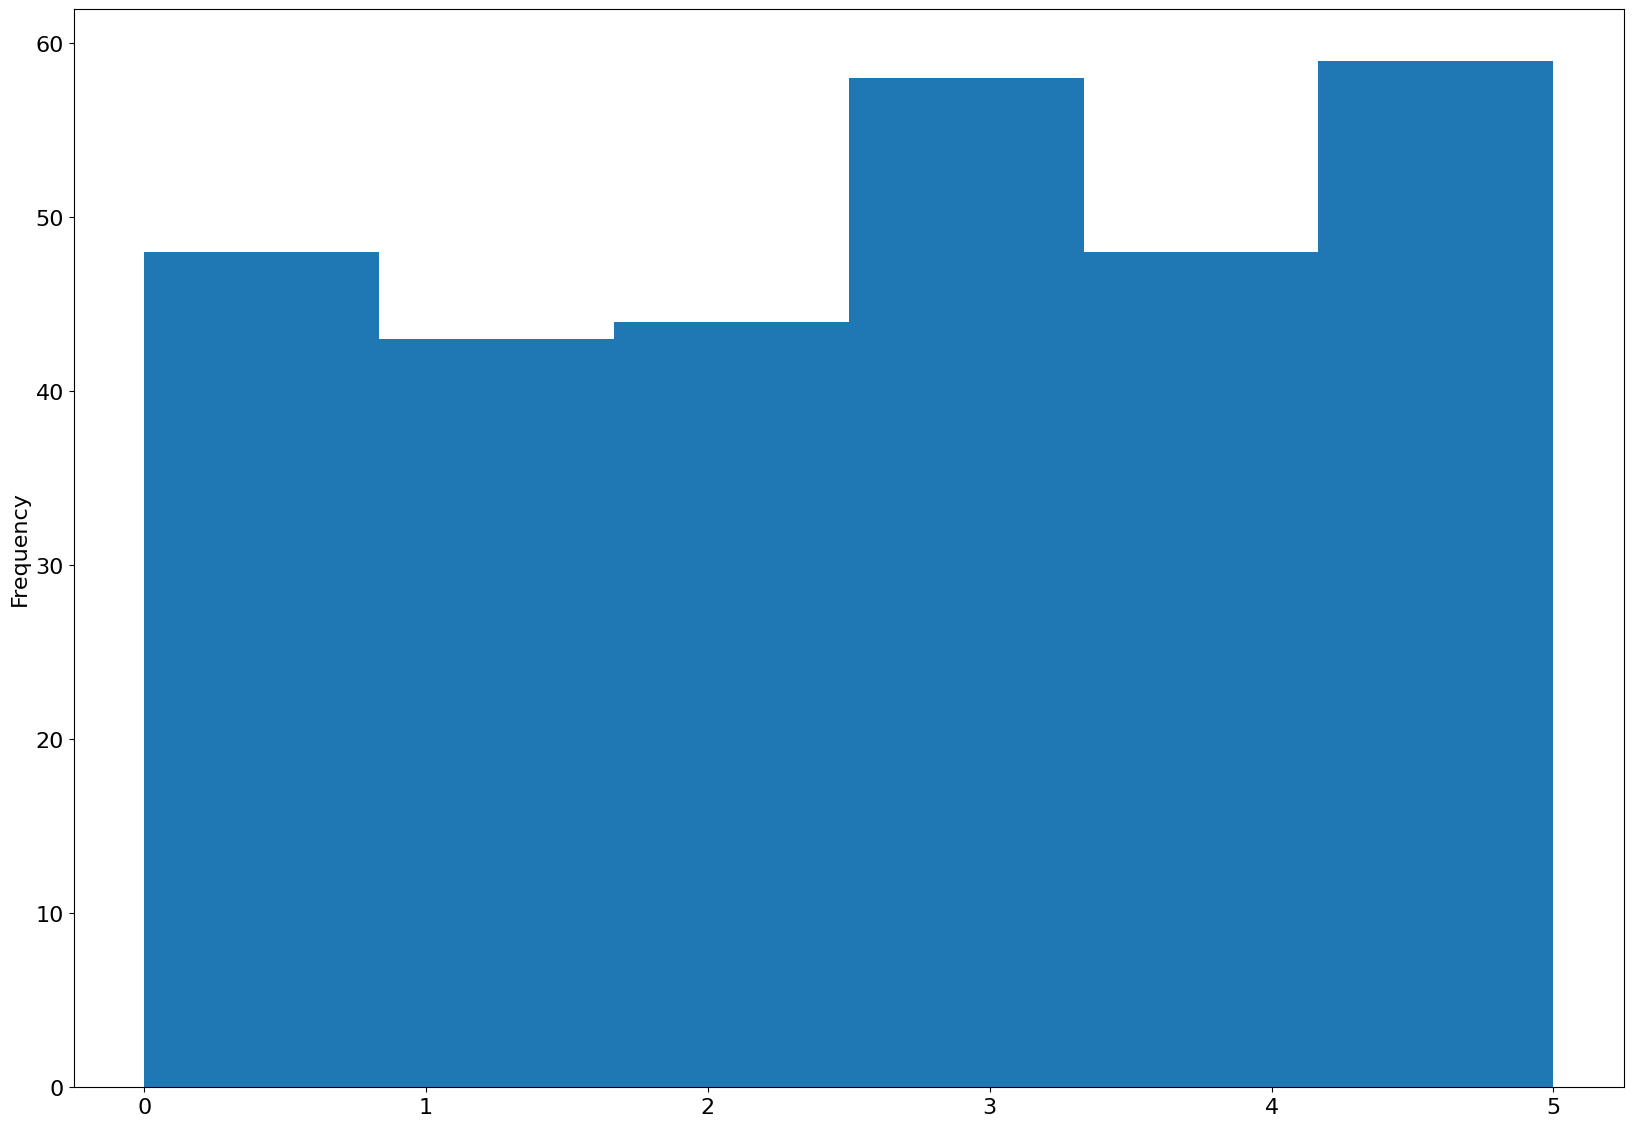

In [93]:
employees_pd['background'].plot.hist(bins =6)

<Axes: ylabel='Frequency'>

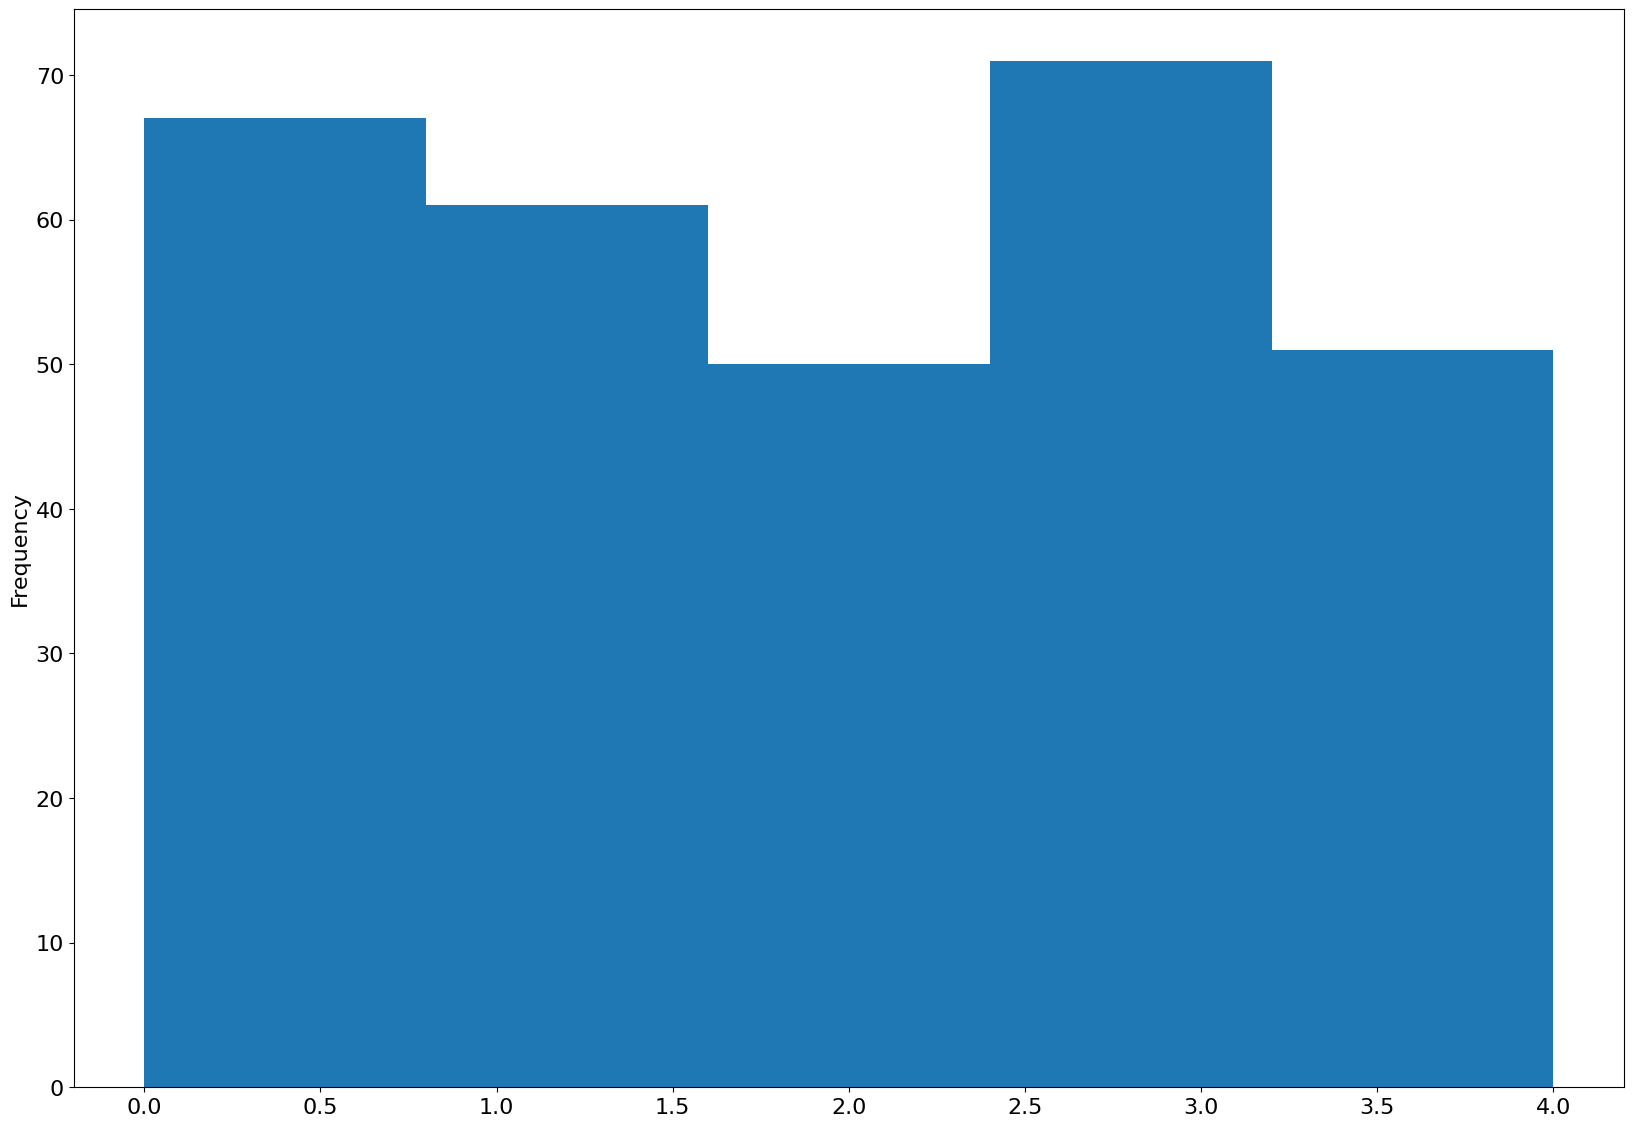

In [94]:
employees_pd['marital status'].plot.hist(bins =5)

<Axes: ylabel='Frequency'>

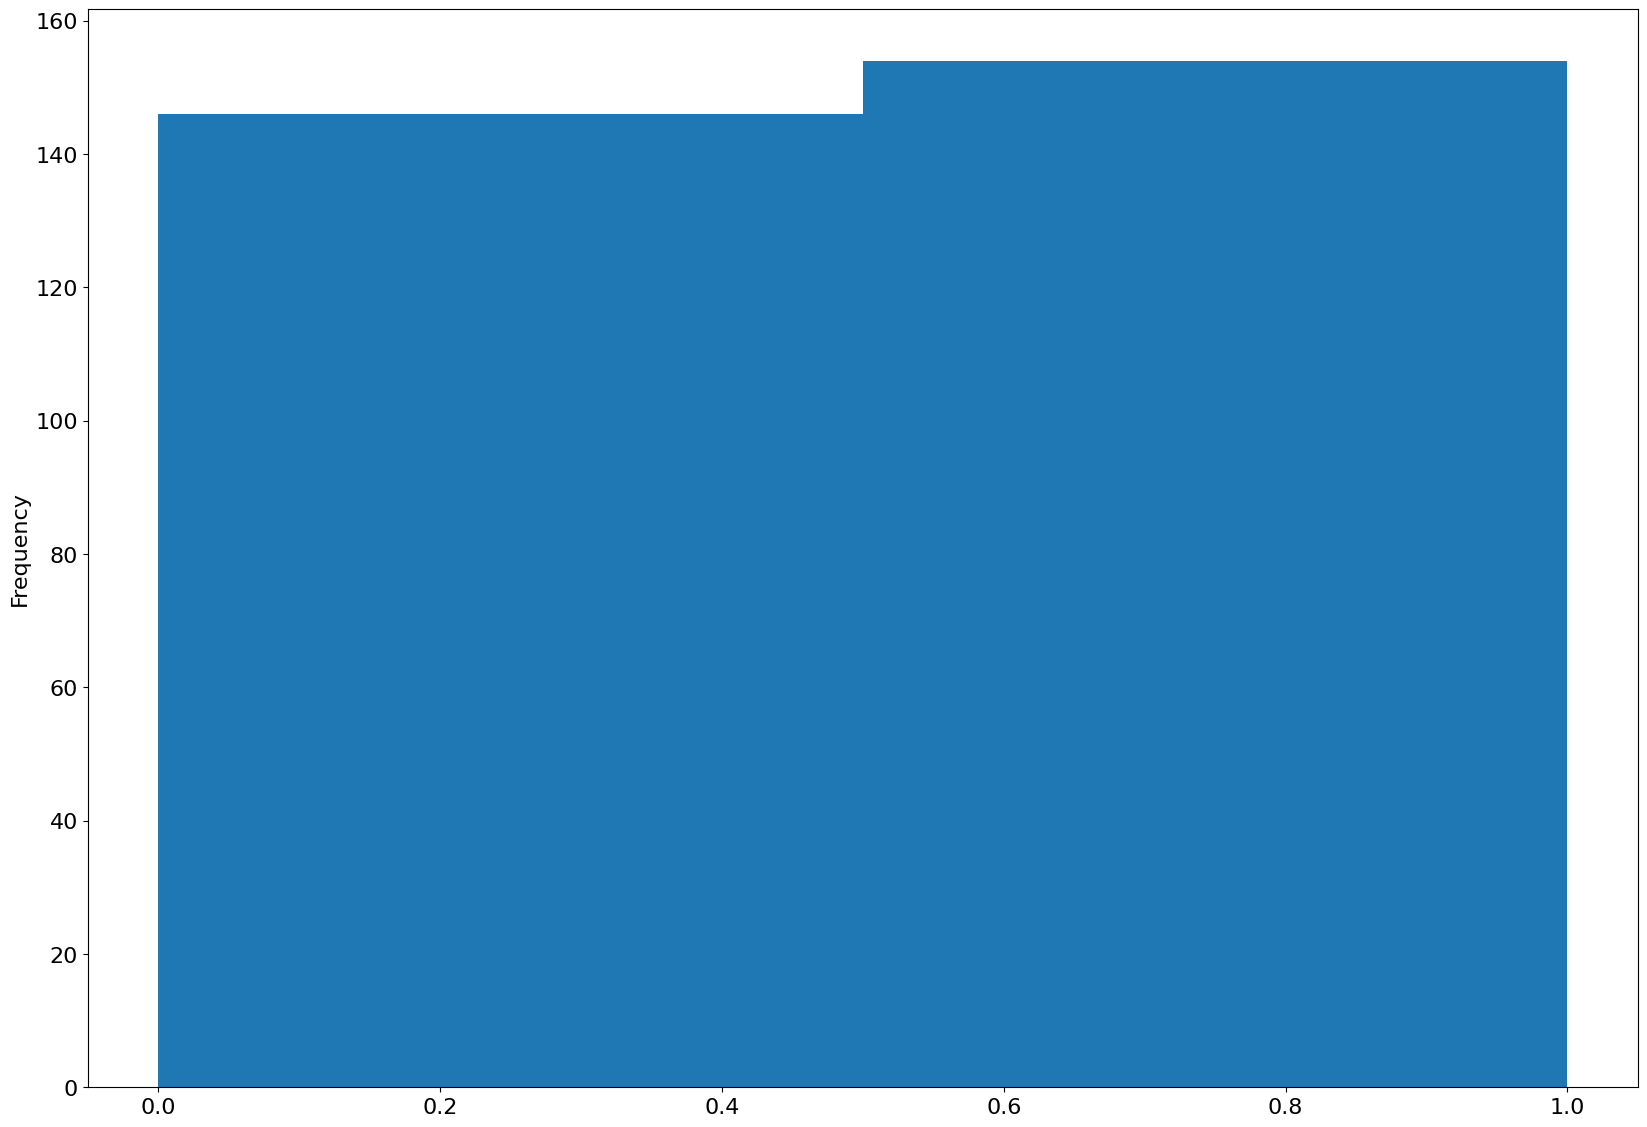

In [95]:
employees_pd['gender'].plot.hist(bins = 2)

# Course dimension


In [96]:
values = range(0,n_courses)
courses = [get_random_string(9) for i in values]
len(courses) 

150

In [97]:
courses[0:5]

['fovvdfgve', 'wpnxftypj', 'ttbledoyq', 'ltcufoqua', 'cuwsgnebl']

In [98]:
values = range(0,n_courses)
course_ids = [get_random_alphanum("COURSE_",4) for i in values]
len(course_ids)

150

In [99]:
course_ids[0:5]

['COURSE_4530', 'COURSE_7065', 'COURSE_5453', 'COURSE_5287', 'COURSE_9481']

In [100]:
values = range(0,n_courses)
levels = [random.choice(level_id) for i in values]
len(levels)

150

In [101]:
levels[0:5]

[2, 4, 2, 1, 2]

In [102]:
values = range(0,n_courses)
skills = [random.choice(roles_pd.skill.unique()) for i in values]
len(skills)

150

In [103]:
skills[0:5]

['1010101294', '1010101691', '1010101693', '1010101040', '1010101954']

In [104]:
data       ={"course_id":course_ids,
             "title":courses,
             "skills": skills,
             "skill level": levels}
courses_pd = pd.DataFrame(data)
courses_pd

,course_id,title,skills,skill level
0,COURSE_4530,fovvdfgve,1010101294,2
1,COURSE_7065,wpnxftypj,1010101691,4
2,COURSE_5453,ttbledoyq,1010101693,2
3,COURSE_5287,ltcufoqua,1010101040,1
4,COURSE_9481,cuwsgnebl,1010101954,2
...,...,...,...,...
145,COURSE_5240,qcxnofnkd,1010101042,2
146,COURSE_5014,qmqckstmz,1010101867,4
147,COURSE_4964,ihyoyhxau,1010101679,3
148,COURSE_3557,cijpyezmc,1010101349,5


## Test

<Axes: ylabel='Frequency'>

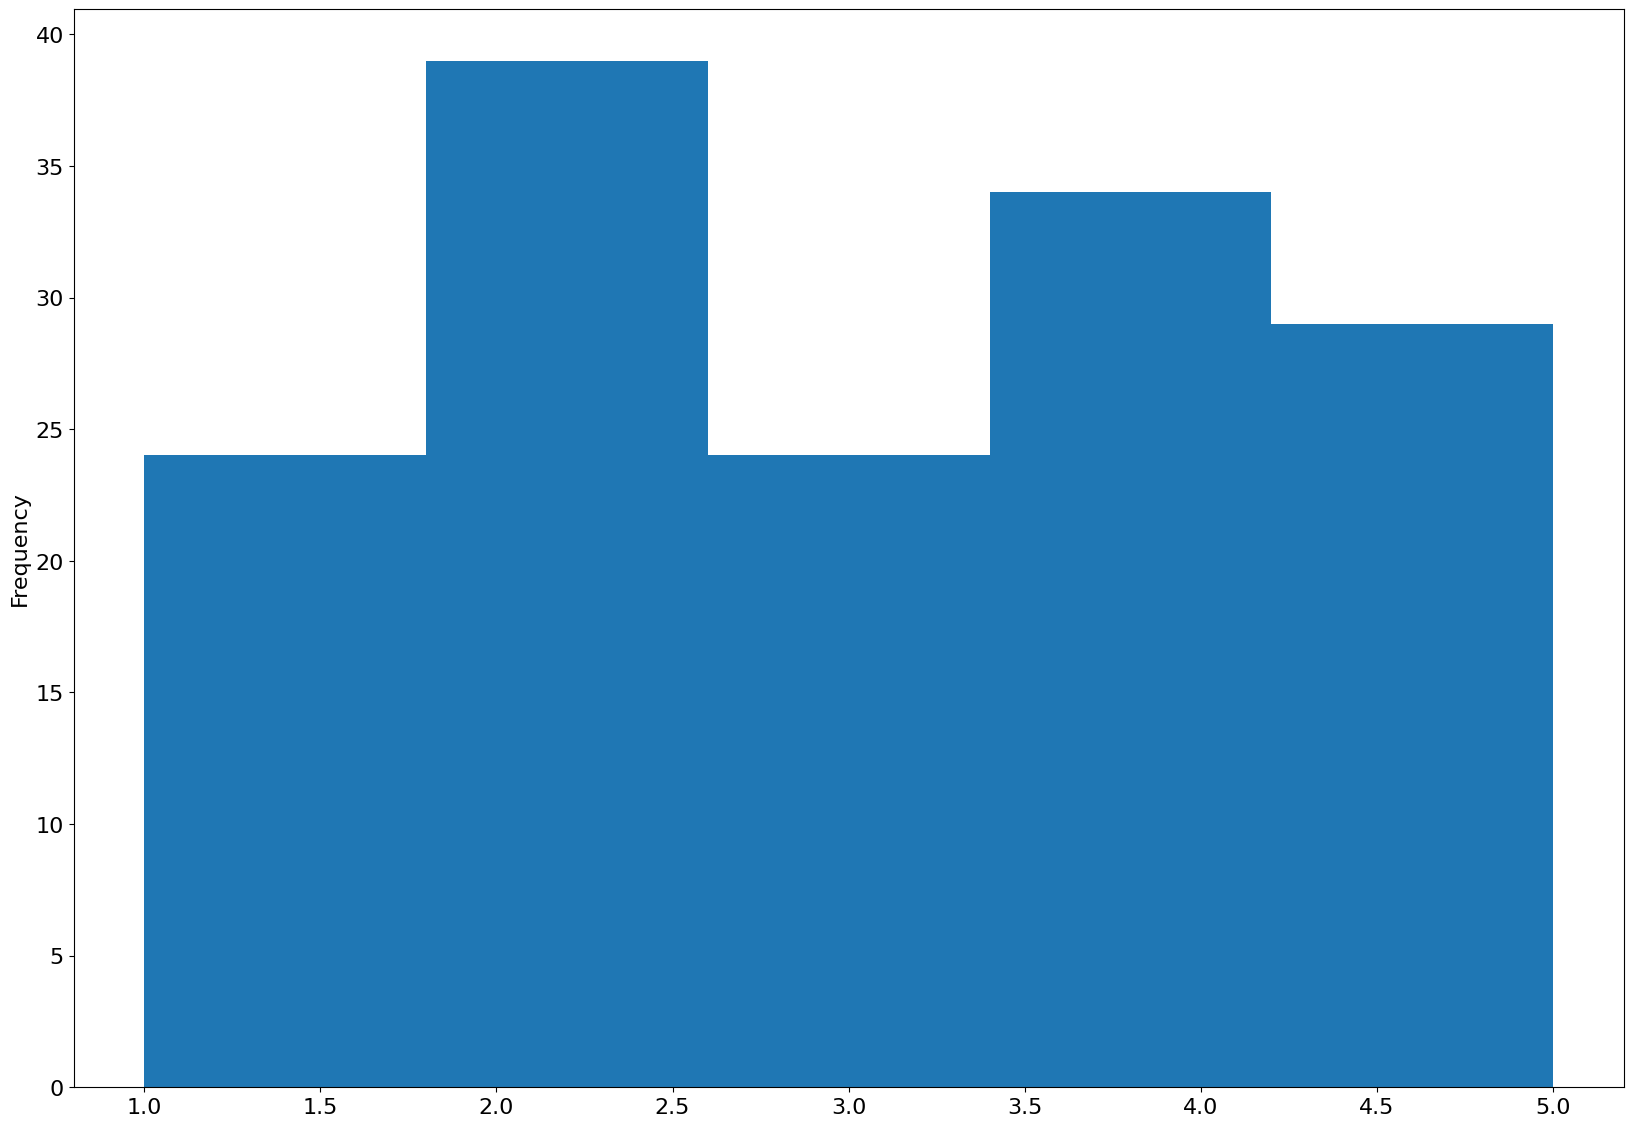

In [105]:
courses_pd['skill level'].plot.hist(bins = 5)


## How can we compare skills?

**dimensions:** 
- skills id
- role id
- role level required
- course-gained
- self-endorsed
- user-endorsed
- soft
- tech
- language
- month
- year 
  
**Measure**
- level

In [106]:
no_items = int(n_skills_matching_employees/4)
no_items

7

In [107]:
roles_ids = np.repeat(random.choice(role_ids), no_items) 
len(roles_ids) == no_items

True

In [108]:
roles_ids[0:5]

array(['ROLE_713858', 'ROLE_713858', 'ROLE_713858', 'ROLE_713858',
       'ROLE_713858'], dtype='<U11')

In [109]:
roles_pd

,role id,role,skill,level
0,ROLE_989543,naqdldozwyh,1010101043,3
1,ROLE_329525,cqljjdixacw,1010101772,3
2,ROLE_025947,sevplprmtbx,1010101176,4
3,ROLE_743948,joyilptjvft,1010101652,5
4,ROLE_482449,aedtathfnkb,1010101910,4
...,...,...,...,...
95,ROLE_281011,enmugvlbsfl,1010101952,5
96,ROLE_943766,kjqoddkwefj,1010101822,3
97,ROLE_185077,pfapomtdxcc,1010101762,3
98,ROLE_440020,zrztiwjkkiv,1010101987,4


In [110]:
values = range(0,no_items)
rows = roles_pd['role id'].isin(roles_ids)
skills_uids = roles_pd.loc[rows,'skill'].to_list()
skills_uids

['1010101122', '1010101762', '1010101873', '1010101767', '1010101767']

In [111]:
gap = no_items - len(skills_uids)
others = [random.choice(skill_ids) for i in range(0,gap)]
skills_uids = skills_uids + others
skills_uids


['1010101122',
 '1010101762',
 '1010101873',
 '1010101767',
 '1010101767',
 '1010101767',
 '1010101772']

In [112]:
type_skills_source = ["self","user","course"]
n_cols = 0 
values = range(0,no_items)

while n_cols < 3: 
    type_source = np.random.choice(type_skills_source,
                               size=no_items, 
                               p=[0.35,0.35,0.30])
    df_encoded = pd.get_dummies(type_source)
    n_cols = df_encoded.shape[1]

df_encoded


,course,self,user
0,False,False,True
1,False,True,False
2,False,False,True
3,True,False,False
4,False,False,True
5,False,False,True
6,False,True,False


In [113]:

levels = np.random.choice([3,4], no_items)
len(levels) == no_items

True

In [114]:
levels

array([3, 3, 3, 4, 4, 3, 3])

In [115]:
months = np.random.choice([1,2,3,4,5,6,7,8,9,10,11,12], no_items)
year  = np.repeat(2024,no_items)
months

array([ 3,  5,  6, 11, 12,  2,  2])

In [116]:
data = {"skill": skills_uids,
        "role": roles_ids,
        "month":months,
        "year":year,
        "level": levels
       }
pd_2024 = pd.DataFrame(data)
pd_2024['self'] = df_encoded['self']
pd_2024['course'] = df_encoded['course']
pd_2024['user'] = df_encoded['user']


pd_2024.dtypes

skill     object
role      object
month      int64
year       int64
level      int64
self        bool
course      bool
user        bool
dtype: object

In [117]:
pd_2024

,skill,role,month,year,level,self,course,user
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True
3,1010101767,ROLE_713858,11,2024,4,False,True,False
4,1010101767,ROLE_713858,12,2024,4,False,False,True
5,1010101767,ROLE_713858,2,2024,3,False,False,True
6,1010101772,ROLE_713858,2,2024,3,True,False,False


In [118]:
pd_2023 = pd_2024.copy(deep = True) 
pd_2023

,skill,role,month,year,level,self,course,user
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True
3,1010101767,ROLE_713858,11,2024,4,False,True,False
4,1010101767,ROLE_713858,12,2024,4,False,False,True
5,1010101767,ROLE_713858,2,2024,3,False,False,True
6,1010101772,ROLE_713858,2,2024,3,True,False,False


In [119]:
pd_2023['role'] = np.repeat(random.choice(role_ids), no_items) 
pd_2023


,skill,role,month,year,level,self,course,user
0,1010101122,ROLE_226242,3,2024,3,False,False,True
1,1010101762,ROLE_226242,5,2024,3,True,False,False
2,1010101873,ROLE_226242,6,2024,3,False,False,True
3,1010101767,ROLE_226242,11,2024,4,False,True,False
4,1010101767,ROLE_226242,12,2024,4,False,False,True
5,1010101767,ROLE_226242,2,2024,3,False,False,True
6,1010101772,ROLE_226242,2,2024,3,True,False,False


In [120]:
values = range(0,no_items)
rows = roles_pd['role id'].isin(pd_2023['role'])
skills_uids = roles_pd.loc[rows,'skill'].to_list()
skills_uids

['1010101525', '1010101263', '1010101122', '1010101043', '1010101954']

In [121]:
gap = no_items - len(skills_uids)

others = [random.choice(skill_ids) for i in range(0,gap)]
skills_uids = skills_uids + others
pd_2023['skill'] = skills_uids


In [122]:
pd_2023['year'] = np.repeat(2023, no_items)
pd_2023['month'] = np.random.choice([1,2,3,4,5,6,7,8,9,10,11,12], pd_2023.shape[0])
pd_2023

,skill,role,month,year,level,self,course,user
0,1010101525,ROLE_226242,2,2023,3,False,False,True
1,1010101263,ROLE_226242,7,2023,3,True,False,False
2,1010101122,ROLE_226242,2,2023,3,False,False,True
3,1010101043,ROLE_226242,12,2023,4,False,True,False
4,1010101954,ROLE_226242,12,2023,4,False,False,True
5,1010101553,ROLE_226242,10,2023,3,False,False,True
6,1010101363,ROLE_226242,10,2023,3,True,False,False


In [123]:
pd_2023.loc[pd_2023.user == True,'self'] = True
pd_2023.loc[pd_2023.user == True,'user'] = False

pd_2023.loc[0:2,['self','course','user']] = [False, True, False]
pd_2023['level'] = np.random.choice([1,2,3], pd_2023.shape[0])


pd_2023



,skill,role,month,year,level,self,course,user
0,1010101525,ROLE_226242,2,2023,2,False,True,False
1,1010101263,ROLE_226242,7,2023,3,False,True,False
2,1010101122,ROLE_226242,2,2023,2,False,True,False
3,1010101043,ROLE_226242,12,2023,1,False,True,False
4,1010101954,ROLE_226242,12,2023,3,True,False,False
5,1010101553,ROLE_226242,10,2023,2,True,False,False
6,1010101363,ROLE_226242,10,2023,1,True,False,False


In [124]:
pd_2025 = pd_2024.copy(deep = True) 
pd_2025

,skill,role,month,year,level,self,course,user
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True
3,1010101767,ROLE_713858,11,2024,4,False,True,False
4,1010101767,ROLE_713858,12,2024,4,False,False,True
5,1010101767,ROLE_713858,2,2024,3,False,False,True
6,1010101772,ROLE_713858,2,2024,3,True,False,False


In [125]:
pd_2025['role'] = np.repeat(random.choice(role_ids), no_items) 
pd_2025


,skill,role,month,year,level,self,course,user
0,1010101122,ROLE_860638,3,2024,3,False,False,True
1,1010101762,ROLE_860638,5,2024,3,True,False,False
2,1010101873,ROLE_860638,6,2024,3,False,False,True
3,1010101767,ROLE_860638,11,2024,4,False,True,False
4,1010101767,ROLE_860638,12,2024,4,False,False,True
5,1010101767,ROLE_860638,2,2024,3,False,False,True
6,1010101772,ROLE_860638,2,2024,3,True,False,False


In [126]:
values = range(0,no_items)
rows = roles_pd['role id'].isin(pd_2025['role'])
skills_uids = roles_pd.loc[rows,'skill'].to_list()
skills_uids

['1010101867', '1010101767', '1010101122', '1010101928', '1010101679']

In [127]:
gap = no_items - len(skills_uids)

others = [random.choice(skill_ids) for i in range(0,gap)]
skills_uids = skills_uids + others
pd_2025['skill'] = skills_uids


In [128]:
pd_2025['skill']

0    1010101867
1    1010101767
2    1010101122
3    1010101928
4    1010101679
5    1010101867
6    1010101721
Name: skill, dtype: object

In [129]:
pd_2025['year'] = np.repeat(2025, no_items)
pd_2025['month'] = np.random.choice([1,2,3,4,5,6,7,8,9,10,11,12], no_items)
pd_2025

,skill,role,month,year,level,self,course,user
0,1010101867,ROLE_860638,9,2025,3,False,False,True
1,1010101767,ROLE_860638,12,2025,3,True,False,False
2,1010101122,ROLE_860638,4,2025,3,False,False,True
3,1010101928,ROLE_860638,10,2025,4,False,True,False
4,1010101679,ROLE_860638,4,2025,4,False,False,True
5,1010101867,ROLE_860638,5,2025,3,False,False,True
6,1010101721,ROLE_860638,3,2025,3,True,False,False


In [130]:
pd_2025.loc[pd_2025.course == True,'level'] = 5
pd_2025.loc[pd_2025.course == True,'course'] = True
pd_2025.loc[pd_2025.course == True,'user'] = False



pd_2025



,skill,role,month,year,level,self,course,user
0,1010101867,ROLE_860638,9,2025,3,False,False,True
1,1010101767,ROLE_860638,12,2025,3,True,False,False
2,1010101122,ROLE_860638,4,2025,3,False,False,True
3,1010101928,ROLE_860638,10,2025,5,False,True,False
4,1010101679,ROLE_860638,4,2025,4,False,False,True
5,1010101867,ROLE_860638,5,2025,3,False,False,True
6,1010101721,ROLE_860638,3,2025,3,True,False,False


In [131]:
skill = np.random.choice(skill_ids,3)
month = [10, 9, 8]
year  = [2025,2025,2025]
level = [4, 4,4] 
self  = [False, False, False]
course = [True, True, True]
user = [False, False, False]
data = {"skill":skill,
        "month":month,
        "year": year,
        "level": level,
        "self": self,
        "course":course,
        "user": user}
pd_2025_new = pd.DataFrame(data)
pd_2025_new

,skill,month,year,level,self,course,user
0,1010101677,10,2025,4,False,True,False
1,1010101693,9,2025,4,False,True,False
2,1010101144,8,2025,4,False,True,False


In [132]:
skills_employee_pd = pd.concat([pd_2023, pd_2024, pd_2025, pd_2025_new])
skills_employee_pd

,skill,role,month,year,level,self,course,user
0,1010101525,ROLE_226242,2,2023,2,False,True,False
1,1010101263,ROLE_226242,7,2023,3,False,True,False
2,1010101122,ROLE_226242,2,2023,2,False,True,False
3,1010101043,ROLE_226242,12,2023,1,False,True,False
4,1010101954,ROLE_226242,12,2023,3,True,False,False
5,1010101553,ROLE_226242,10,2023,2,True,False,False
6,1010101363,ROLE_226242,10,2023,1,True,False,False
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True


In [133]:
rows = skills_employee_pd.year == 2025
skills_employee_pd.loc[rows,'role'] = np.repeat(skills_employee_pd.loc[rows,'role'].unique()[0],
                                                skills_employee_pd.loc[rows,'role'].shape[0])
skills_employee_pd.shape


(24, 8)

In [134]:
skills_employee_pd

,skill,role,month,year,level,self,course,user
0,1010101525,ROLE_226242,2,2023,2,False,True,False
1,1010101263,ROLE_226242,7,2023,3,False,True,False
2,1010101122,ROLE_226242,2,2023,2,False,True,False
3,1010101043,ROLE_226242,12,2023,1,False,True,False
4,1010101954,ROLE_226242,12,2023,3,True,False,False
5,1010101553,ROLE_226242,10,2023,2,True,False,False
6,1010101363,ROLE_226242,10,2023,1,True,False,False
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True


In [135]:
skills_pd.head()

,skills_uid,skills,language,technical,soft,cluster
0,1010101263,gqryuk,False,True,False,2020202265
1,1010101987,goaylk,True,False,False,2020202454
2,1010101349,bdbluo,True,False,False,2020202005
3,1010101080,bsncme,False,True,False,2020202005
4,1010101952,bxxnst,False,False,True,2020202703


In [136]:
emp = skills_employee_pd.merge(skills_pd, 
                               left_on="skill", 
                               right_on="skills_uid")
emp.dtypes

skill         object
role          object
month          int64
year           int64
level          int64
self            bool
course          bool
user            bool
skills_uid    object
skills        object
language        bool
technical       bool
soft            bool
cluster       object
dtype: object

In [137]:
emp.year.unique()

array([2023, 2024, 2025])

## Skills development 

In [138]:

t = emp.loc[:, ['skills','level']].groupby(['skills']).describe().reset_index()
t.columns = t.columns.map('_'.join)
t.dtypes


skills_         object
level_count    float64
level_mean     float64
level_std      float64
level_min      float64
level_25%      float64
level_50%      float64
level_75%      float64
level_max      float64
dtype: object

In [139]:
t

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,skills_,level_count,level_mean,level_std,level_min,level_25%,level_50%,level_75%,level_max
0,gbhazb,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0
1,gqryuk,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0
2,idrtpm,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
3,ieecmo,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0
4,ijzffe,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0
5,ilkukl,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0
6,iriayl,1.0,5.000000,NaN,5.0,5.0,5.0,5.0,5.0
7,jbkamg,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0
8,jisdwl,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0
9,jnfqct,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0


# Personal profile

## Skills level and development

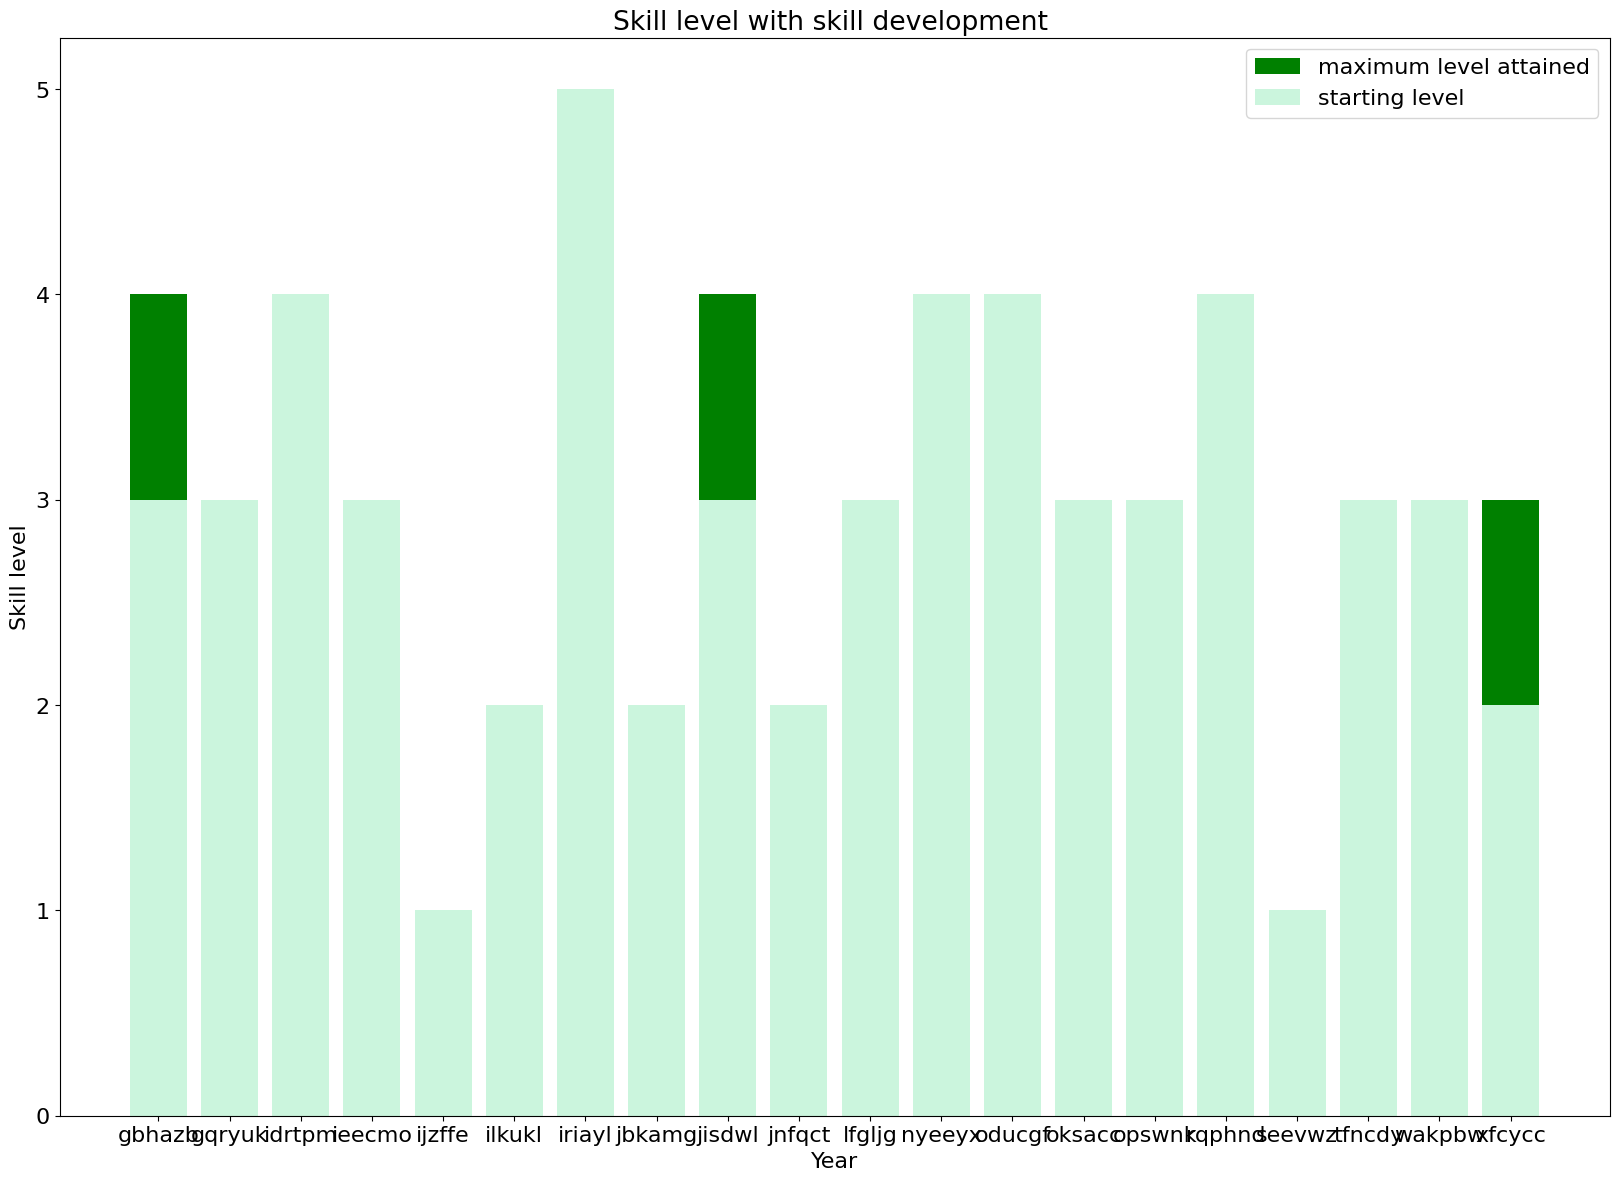

In [140]:
X = t.loc[:,'skills_'].to_list()
Y_max = t.loc[:,'level_max'].to_list()
Y_min = t.loc[:,'level_min'].to_list()
plt.bar(X, Y_max, color="green", label="maximum level attained")
plt.bar(X, Y_min, color='#cbf5dd', label= "starting level")
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Skill level")
plt.title("Skill level with skill development ")
plt.legend()
plt.show()

In [141]:
emp.dtypes

skill         object
role          object
month          int64
year           int64
level          int64
self            bool
course          bool
user            bool
skills_uid    object
skills        object
language        bool
technical       bool
soft            bool
cluster       object
dtype: object

In [142]:
emp

,skill,role,month,year,level,self,course,user,skills_uid,skills,language,technical,soft,cluster
0,1010101525,ROLE_226242,2,2023,2,False,True,False,1010101525,ilkukl,False,False,True,2020202378
1,1010101263,ROLE_226242,7,2023,3,False,True,False,1010101263,gqryuk,False,True,False,2020202265
2,1010101122,ROLE_226242,2,2023,2,False,True,False,1010101122,xfcycc,True,False,False,2020202999
3,1010101043,ROLE_226242,12,2023,1,False,True,False,1010101043,ijzffe,False,True,False,2020202378
4,1010101954,ROLE_226242,12,2023,3,True,False,False,1010101954,ieecmo,False,False,True,2020202215
5,1010101553,ROLE_226242,10,2023,2,True,False,False,1010101553,jnfqct,True,False,False,2020202379
6,1010101553,ROLE_226242,10,2023,2,True,False,False,1010101553,jbkamg,False,True,False,2020202999
7,1010101363,ROLE_226242,10,2023,1,True,False,False,1010101363,seevwz,False,False,True,2020202342
8,1010101122,ROLE_713858,3,2024,3,False,False,True,1010101122,xfcycc,True,False,False,2020202999
9,1010101762,ROLE_713858,5,2024,3,True,False,False,1010101762,oksacc,False,False,True,2020202005


In [143]:
cols =['month','year','self','course','user','language','technical','soft','skills','level']
emp = emp[cols]
emp


,month,year,self,course,user,language,technical,soft,skills,level
0,2,2023,False,True,False,False,False,True,ilkukl,2
1,7,2023,False,True,False,False,True,False,gqryuk,3
2,2,2023,False,True,False,True,False,False,xfcycc,2
3,12,2023,False,True,False,False,True,False,ijzffe,1
4,12,2023,True,False,False,False,False,True,ieecmo,3
5,10,2023,True,False,False,True,False,False,jnfqct,2
6,10,2023,True,False,False,False,True,False,jbkamg,2
7,10,2023,True,False,False,False,False,True,seevwz,1
8,3,2024,False,False,True,True,False,False,xfcycc,3
9,5,2024,True,False,False,False,False,True,oksacc,3


In [144]:
skills_level = emp.groupby(['year']).describe()['level'].reset_index()
skills_level  = pd.DataFrame(skills_level)
skills_level


,year,count,mean,std,min,25%,50%,75%,max
0,2023,8.0,2.000000,0.755929,1.0,1.75,2.0,2.25,3.0
1,2024,10.0,3.400000,0.516398,3.0,3.00,3.0,4.00,4.0
2,2025,11.0,3.545455,0.687552,3.0,3.00,3.0,4.00,5.0


In [145]:
skills_level.loc[:,['year','mean','std']]

,year,mean,std
0,2023,2.000000,0.755929
1,2024,3.400000,0.516398
2,2025,3.545455,0.687552


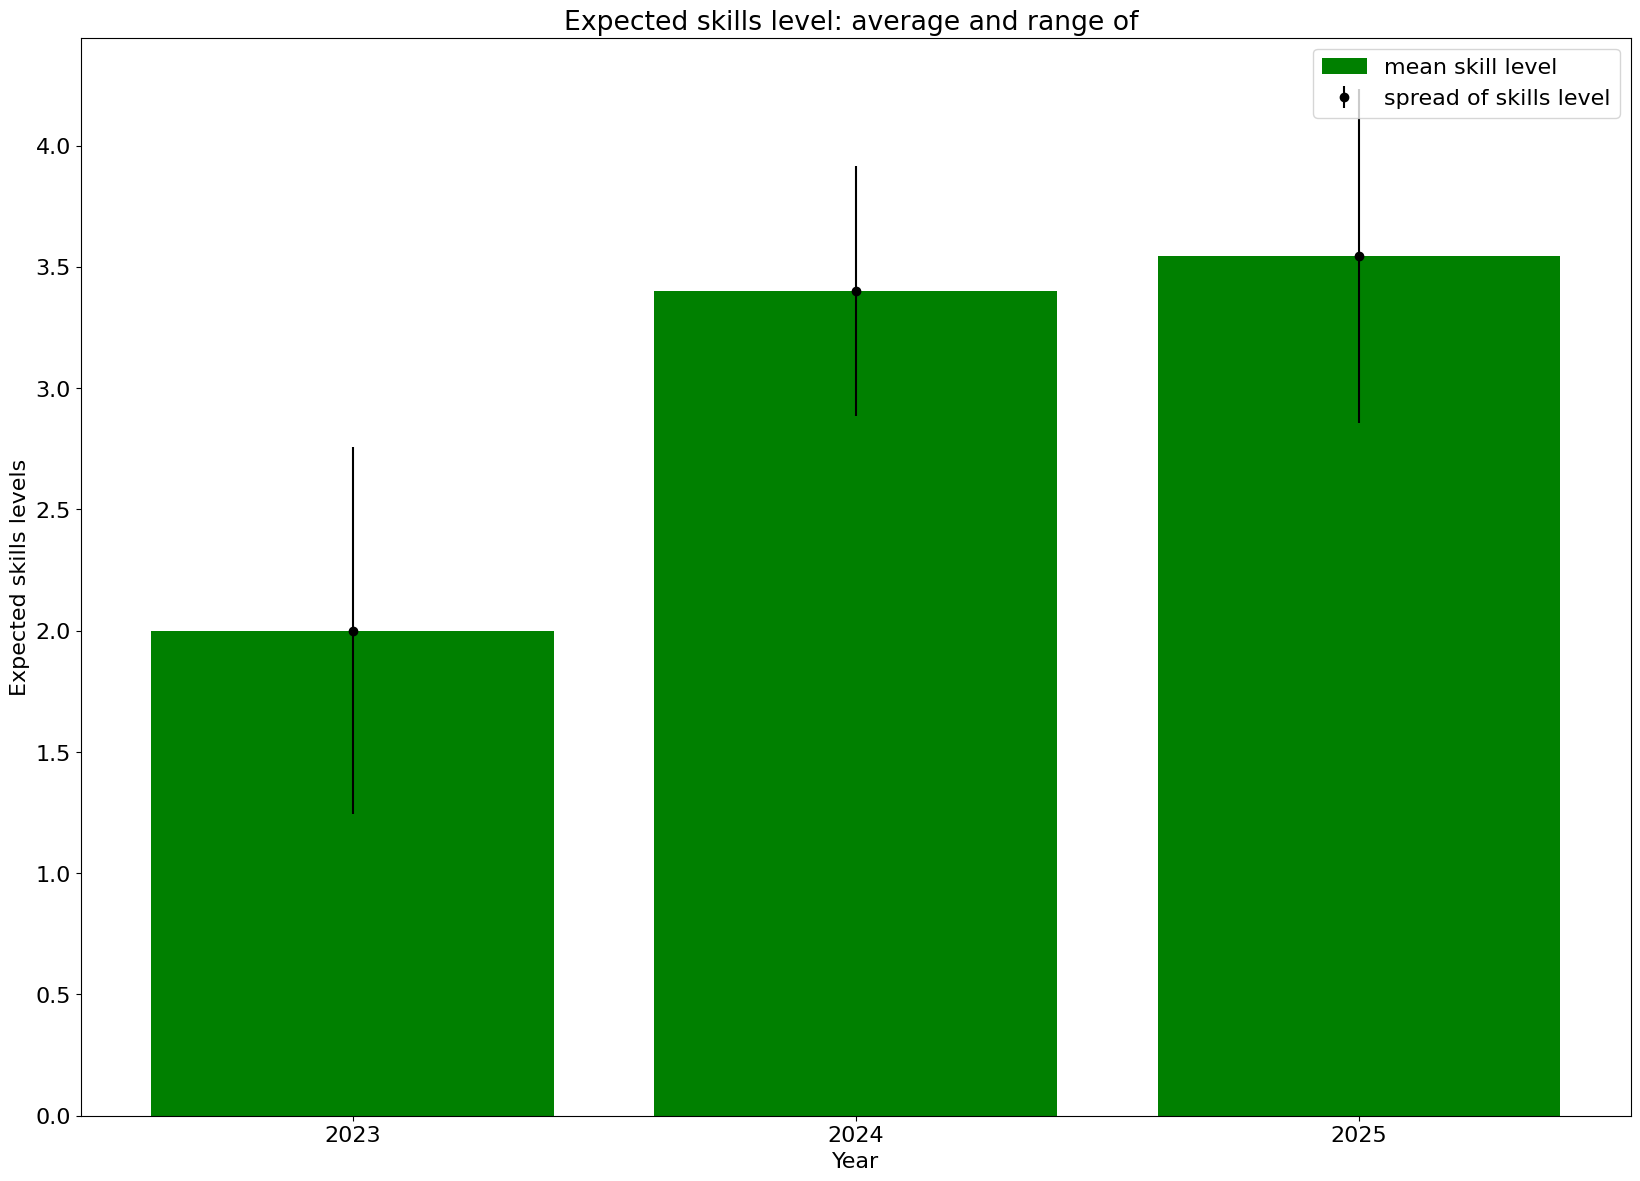

In [146]:
X = skills_level.loc[:,'year'].to_list()
Y = skills_level.loc[:,'mean'].to_list()
err = skills_level.loc[:,'std'].to_list()
plt.bar(X, Y, color="green", label='mean skill level')
plt.errorbar(X, Y, yerr=err, fmt="o", color="black", label='spread of skills level')
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Expected skills levels")
plt.title("Expected skills level: average and range of ")
plt.legend()
plt.show()

## Skill developments through time

In [147]:
emp_users  = emp.loc[emp.user == True, :]
emp_self   = emp.loc[emp.self == True, :]
emp_course = emp.loc[emp.course == True, :]


Text(0.5, 1.0, 'Skills development through courses')

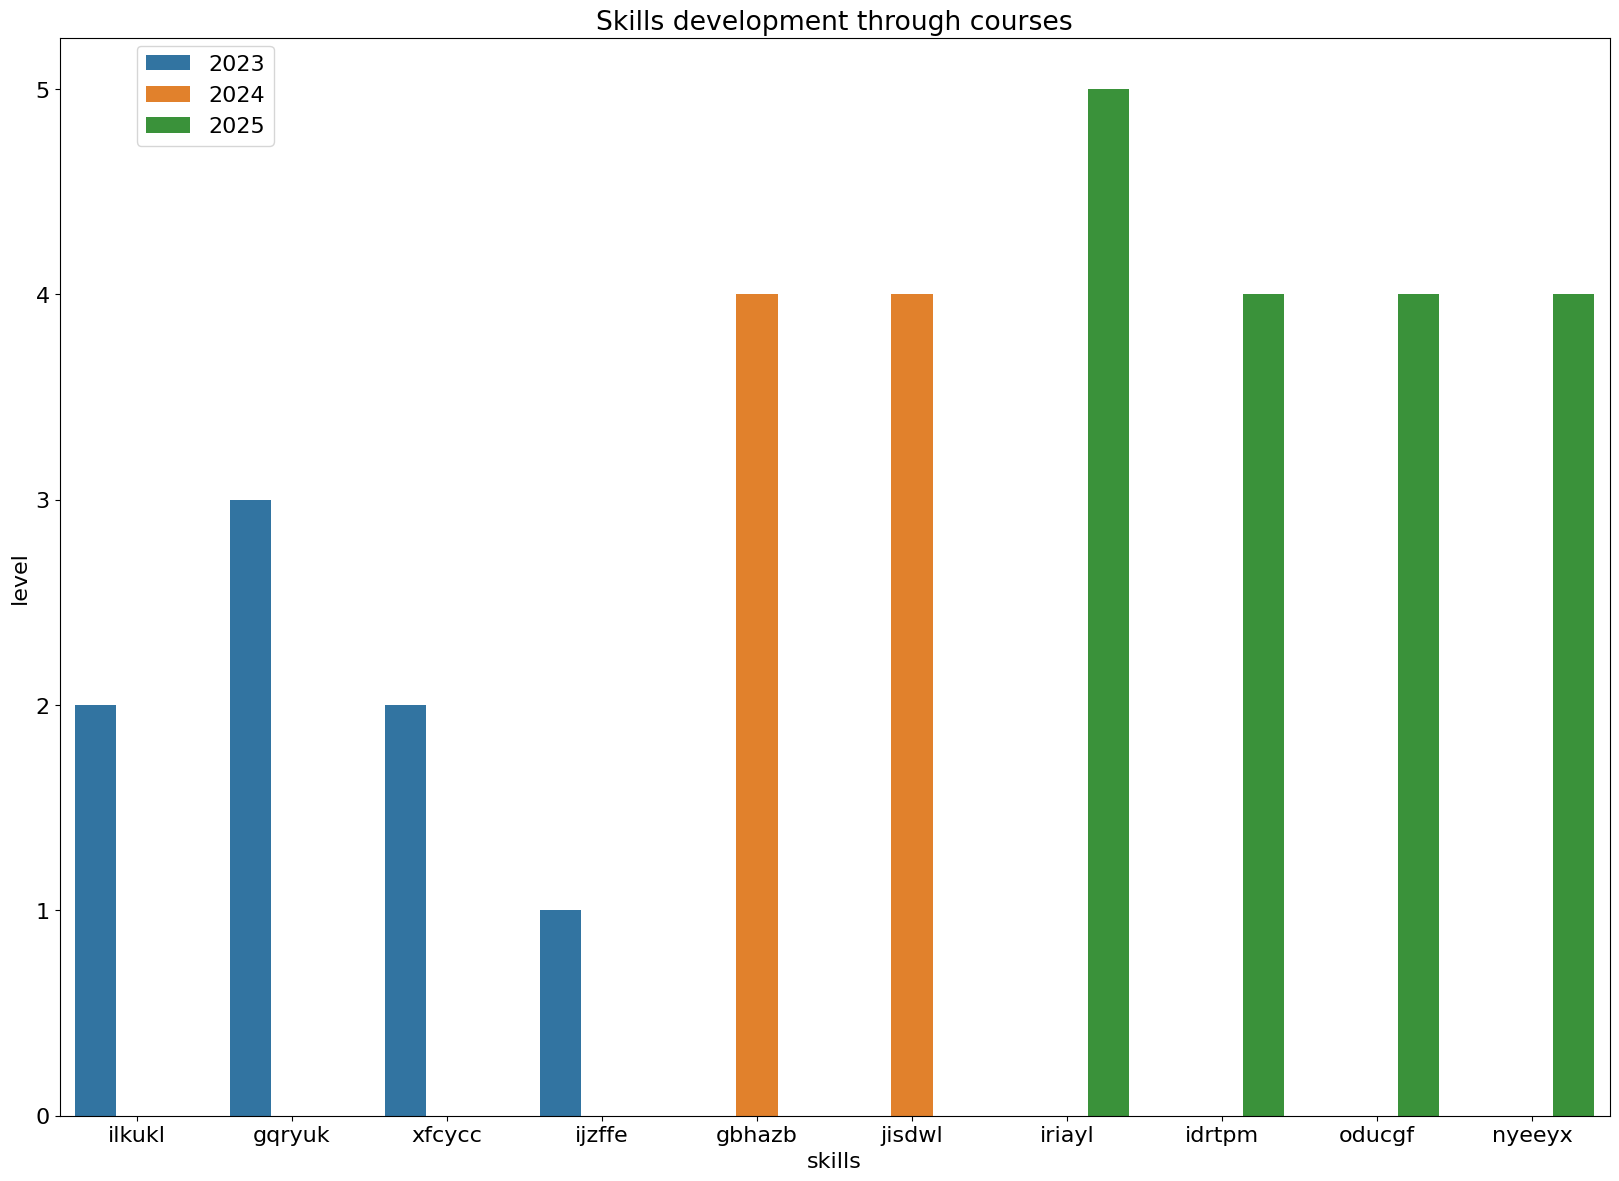

In [148]:
ax = sns.barplot(data=emp_course,
            x="skills",
            y="level",
            hue="year")
plt.legend(loc=(0.05, 0.90))
plt.title('Skills development through courses')

Text(0.5, 1.0, 'Skills development through self-assessment')

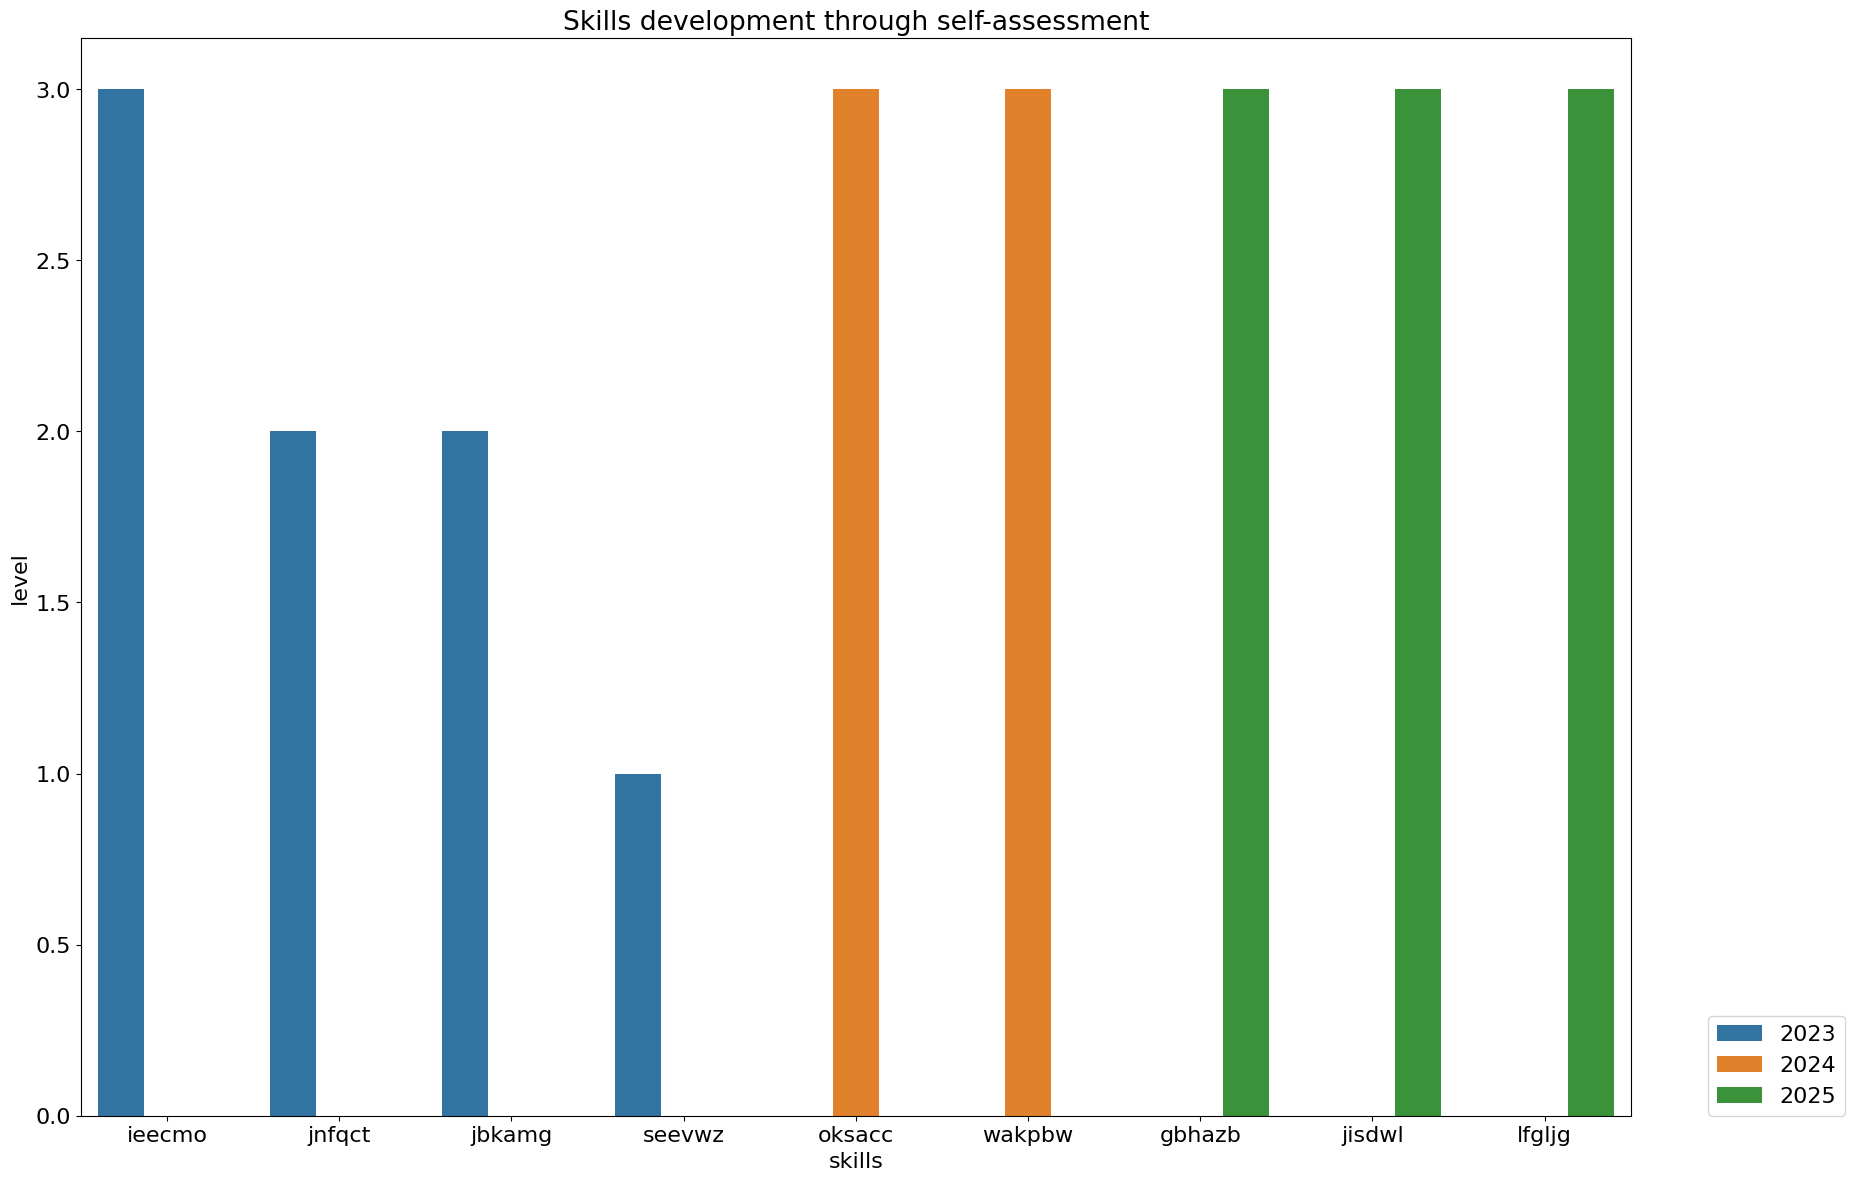

In [149]:
ax = sns.barplot(data=emp_self,
            x="skills",
            y="level",
            hue="year")
plt.legend(loc=(1.05, 0))
plt.title('Skills development through self-assessment')

Text(0.5, 1.0, 'Skills development through user endorsement')

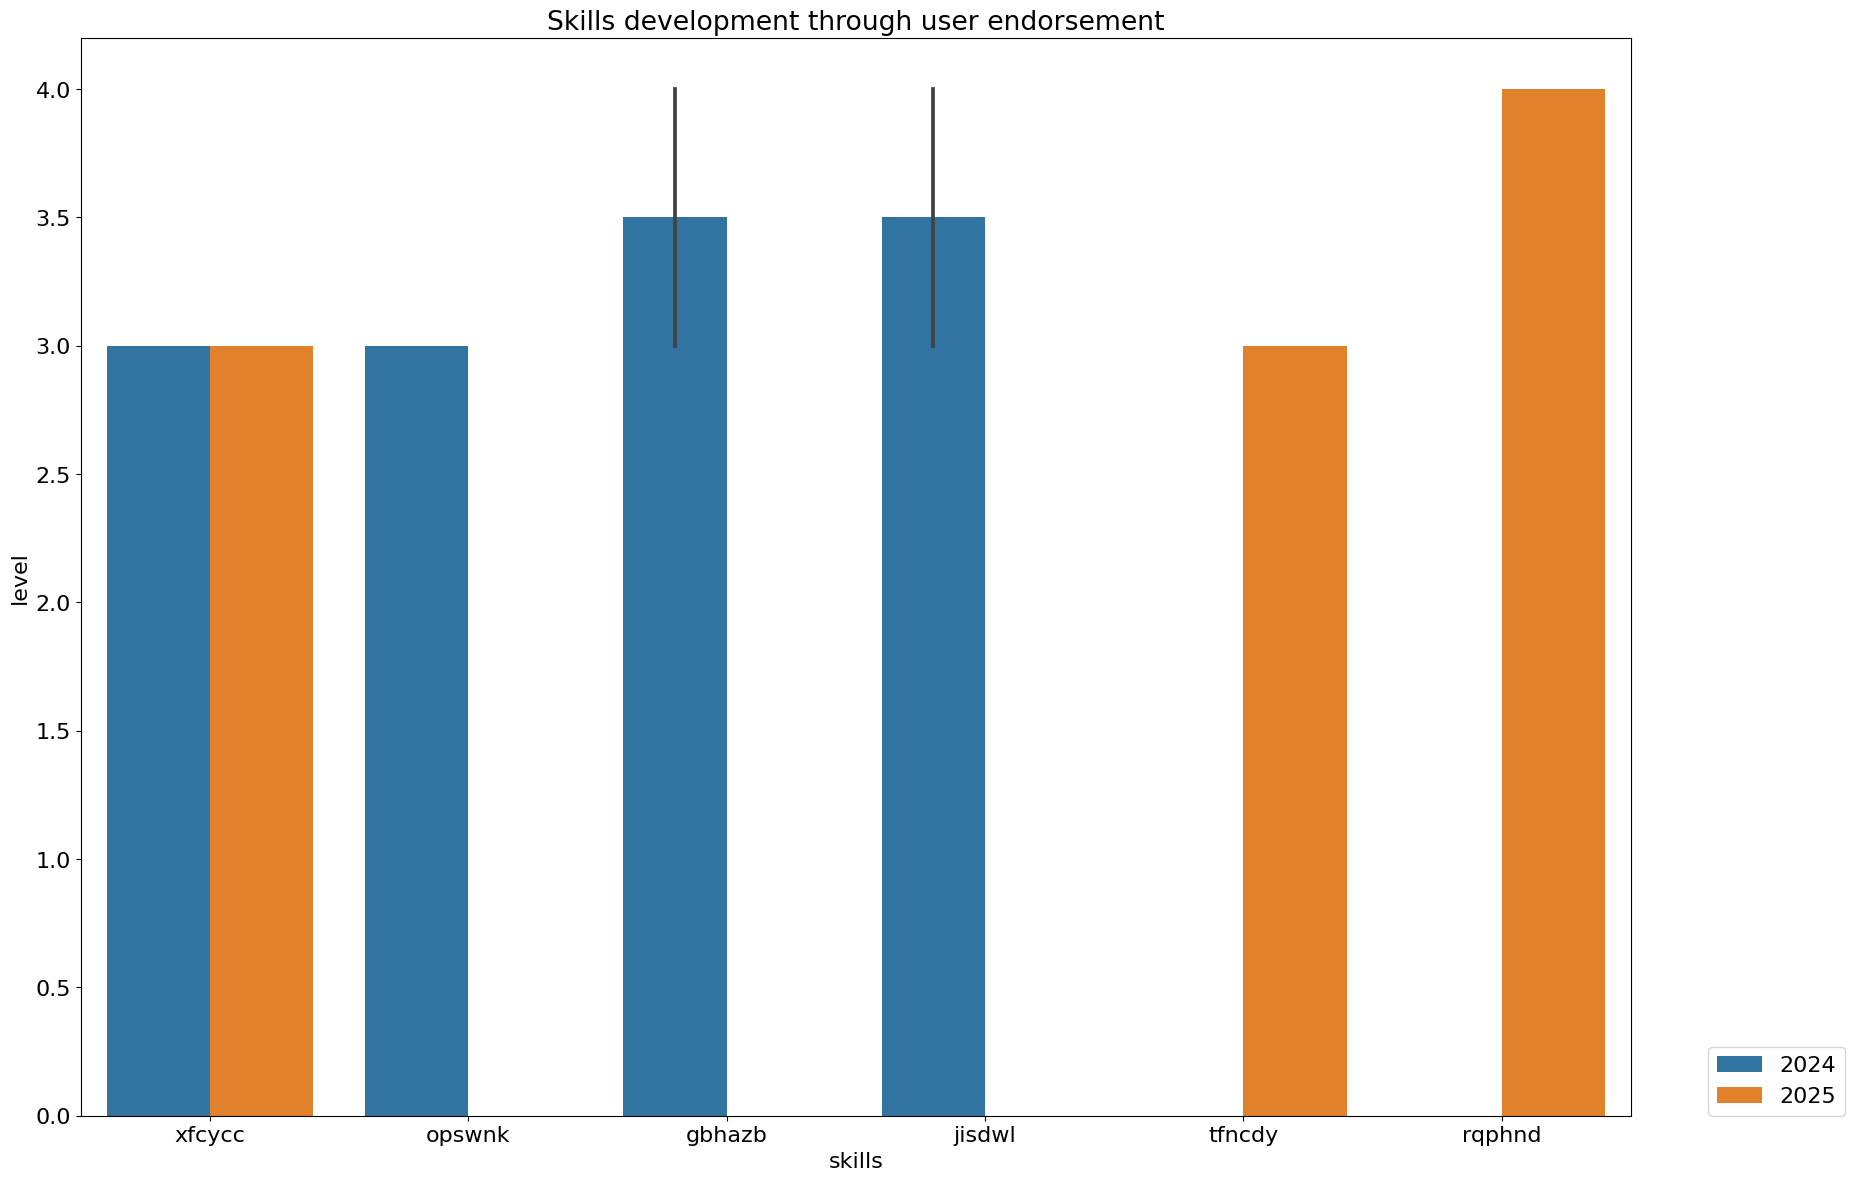

In [150]:
ax = sns.barplot(data=emp_users,
            x="skills",
            y="level",
            hue="year")
plt.legend(loc=(1.05, 0))
plt.title('Skills development through user endorsement')

In [151]:
emp

,month,year,self,course,user,language,technical,soft,skills,level
0,2,2023,False,True,False,False,False,True,ilkukl,2
1,7,2023,False,True,False,False,True,False,gqryuk,3
2,2,2023,False,True,False,True,False,False,xfcycc,2
3,12,2023,False,True,False,False,True,False,ijzffe,1
4,12,2023,True,False,False,False,False,True,ieecmo,3
5,10,2023,True,False,False,True,False,False,jnfqct,2
6,10,2023,True,False,False,False,True,False,jbkamg,2
7,10,2023,True,False,False,False,False,True,seevwz,1
8,3,2024,False,False,True,True,False,False,xfcycc,3
9,5,2024,True,False,False,False,False,True,oksacc,3


## Type of skills 
### Proportion

<BarContainer object of 3 artists>

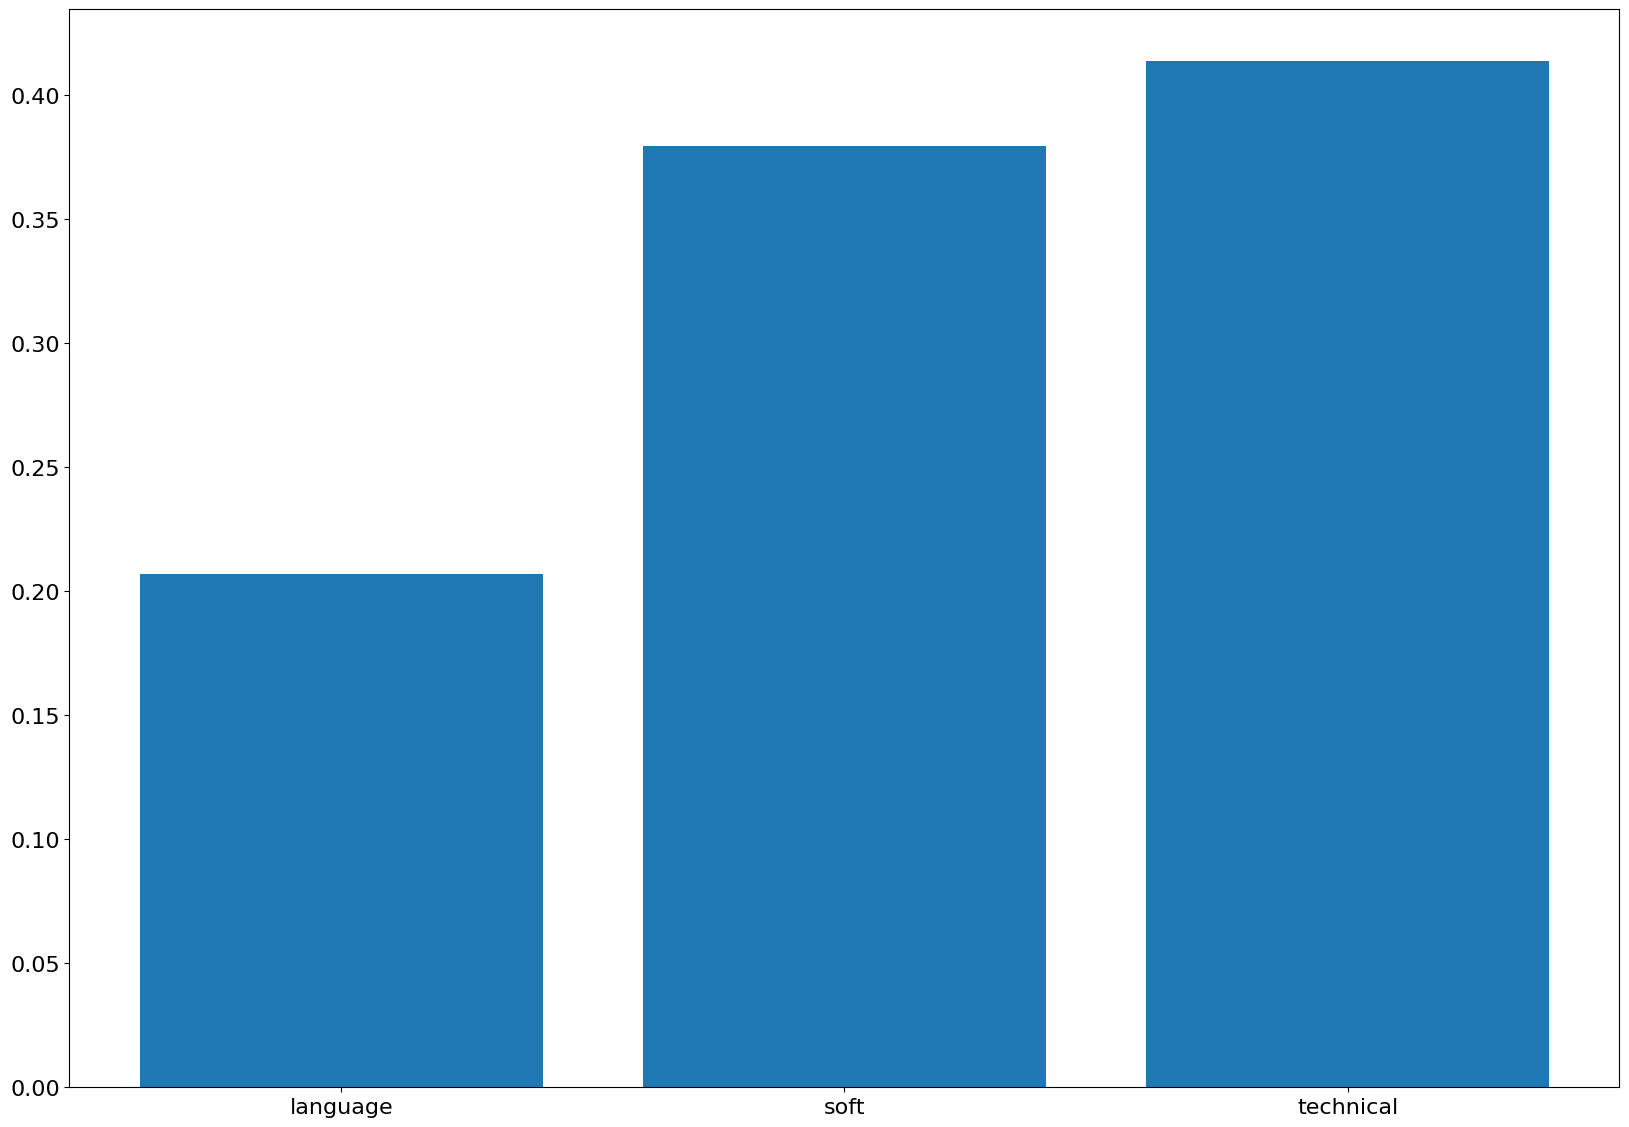

In [152]:
n_language = emp.loc[emp.language == True, :].shape[0]
n_soft     = emp.loc[emp.soft == True, :].shape[0]
n_tech     = emp.loc[emp.technical == True, :].shape[0]
n_total    = emp.shape[0]

X = ["language", "soft","technical"]
Y = [n_language/n_total, n_soft/n_total, n_tech/n_total]
plt.figure(figsize=(20,14))
plt.bar(X, Y)




In [153]:
skills_employee_pd

,skill,role,month,year,level,self,course,user
0,1010101525,ROLE_226242,2,2023,2,False,True,False
1,1010101263,ROLE_226242,7,2023,3,False,True,False
2,1010101122,ROLE_226242,2,2023,2,False,True,False
3,1010101043,ROLE_226242,12,2023,1,False,True,False
4,1010101954,ROLE_226242,12,2023,3,True,False,False
5,1010101553,ROLE_226242,10,2023,2,True,False,False
6,1010101363,ROLE_226242,10,2023,1,True,False,False
0,1010101122,ROLE_713858,3,2024,3,False,False,True
1,1010101762,ROLE_713858,5,2024,3,True,False,False
2,1010101873,ROLE_713858,6,2024,3,False,False,True


In [154]:
t =emp.loc[:,['language','technical','soft','skills','level']].groupby(['language','technical','soft','skills']).describe().reset_index()
t.columns = t.columns.map('_'.join)
t


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,language_,technical_,soft_,skills_,level_count,level_mean,level_std,level_min,level_25%,level_50%,level_75%,level_max
0,False,False,True,ieecmo,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0
1,False,False,True,ilkukl,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0
2,False,False,True,iriayl,1.0,5.000000,NaN,5.0,5.0,5.0,5.0,5.0
3,False,False,True,jisdwl,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0
4,False,False,True,oksacc,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0
5,False,False,True,opswnk,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0
6,False,False,True,rqphnd,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
7,False,False,True,seevwz,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0
8,False,True,False,gbhazb,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0
9,False,True,False,gqryuk,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0


In [155]:
rows = t.soft_ == True
t.loc[rows,'type'] = "Soft skills"
rows = t.language_ == True
t.loc[rows,'type'] = "Language skills"
rows = t.technical_ == True
t.loc[rows,'type'] = "Technical skills"

t

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,language_,technical_,soft_,skills_,level_count,level_mean,level_std,level_min,level_25%,level_50%,level_75%,level_max,type
0,False,False,True,ieecmo,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0,Soft skills
1,False,False,True,ilkukl,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0,Soft skills
2,False,False,True,iriayl,1.0,5.000000,NaN,5.0,5.0,5.0,5.0,5.0,Soft skills
3,False,False,True,jisdwl,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0,Soft skills
4,False,False,True,oksacc,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0,Soft skills
5,False,False,True,opswnk,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0,Soft skills
6,False,False,True,rqphnd,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0,Soft skills
7,False,False,True,seevwz,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0,Soft skills
8,False,True,False,gbhazb,4.0,3.500000,0.57735,3.0,3.0,3.5,4.0,4.0,Technical skills
9,False,True,False,gqryuk,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0,Technical skills


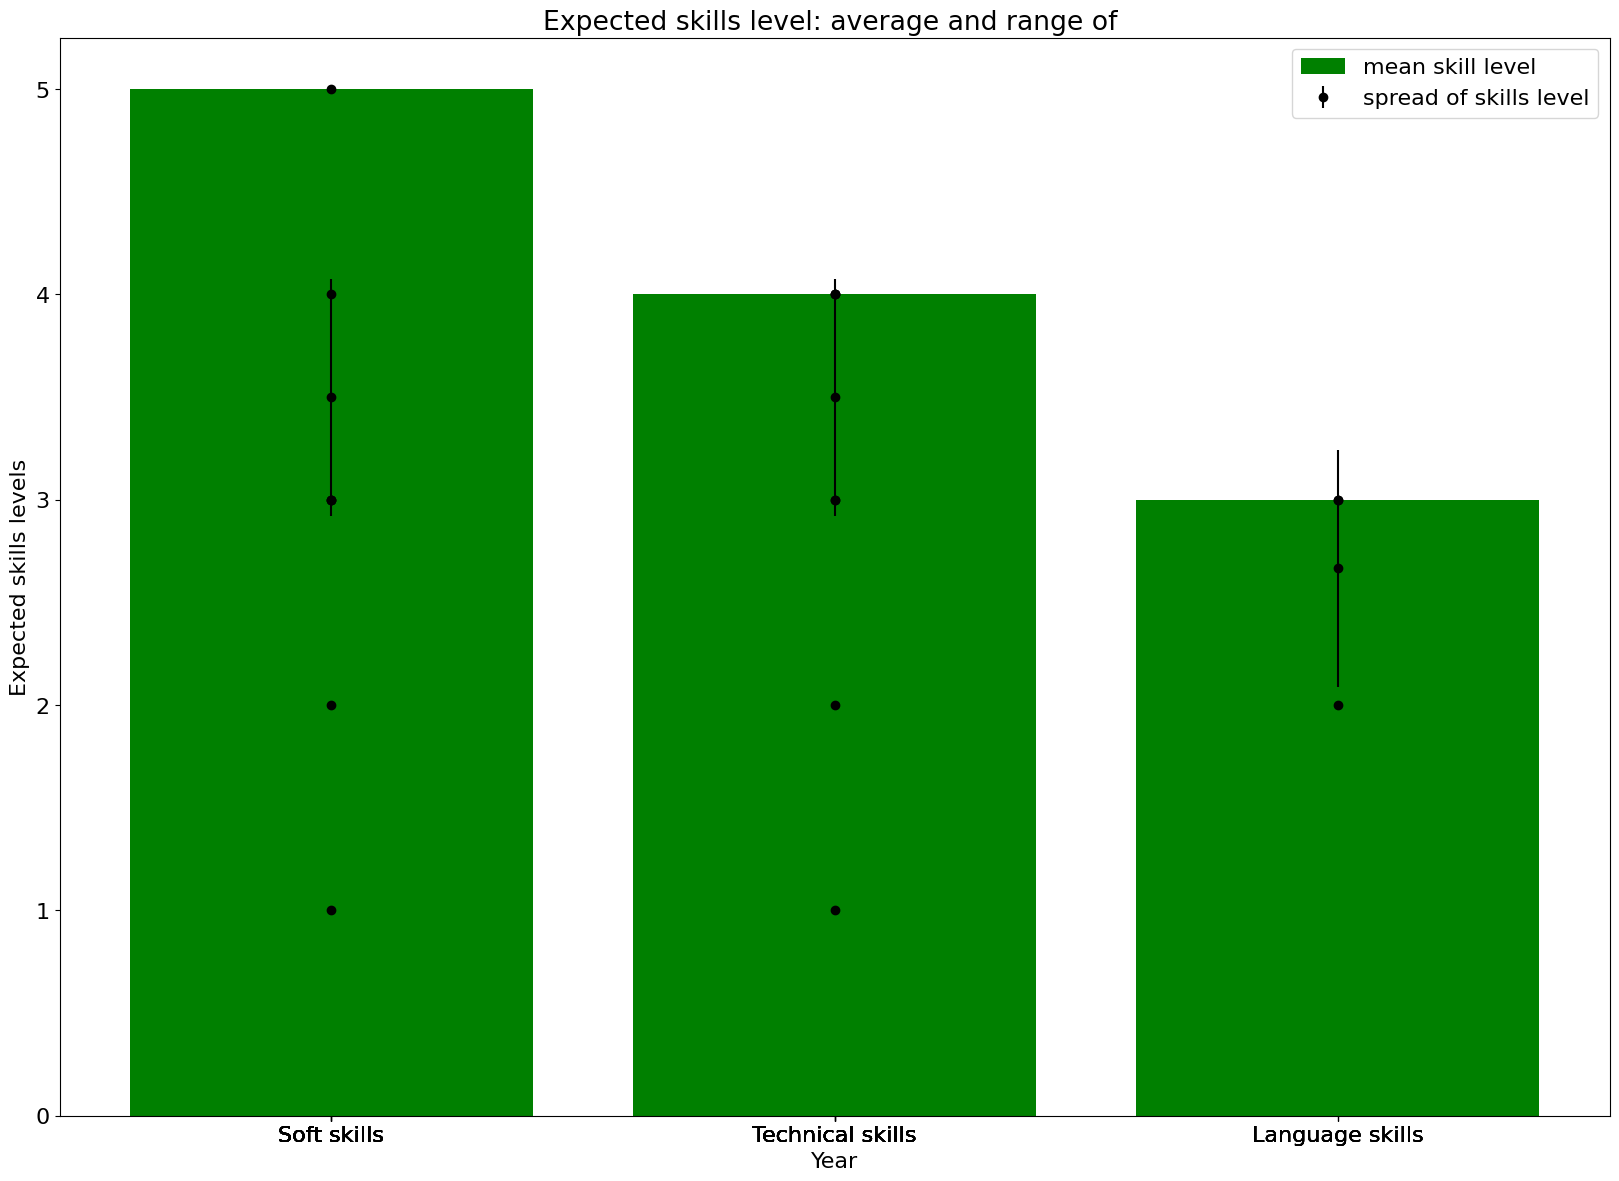

In [156]:
X = t.loc[:,'type'].to_list()
Y = t.loc[:,'level_mean'].to_list()
err = t.loc[:,'level_std'].to_list()
plt.bar(X, Y, color="green", label='mean skill level')
plt.errorbar(X, Y, yerr=err, fmt="o", color="black", label='spread of skills level')
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Expected skills levels")
plt.title("Expected skills level: average and range of ")
plt.legend()
plt.show()

# Skills comparison against role


In [157]:
roles = list(skills_employee_pd.role.unique())

In [158]:
skills_employee_pd.dtypes

skill     object
role      object
month      int64
year       int64
level      int64
self        bool
course      bool
user        bool
dtype: object

In [159]:
skills_type = skills_employee_pd.loc[:,['self','user','course']].idxmax(axis=1)
skills_employee_pd['source']  = skills_type
columns = ['skill','role','month','year','level','source']
skills_employee_pd = skills_employee_pd.loc[:, columns]
skills_employee_pd.shape


(24, 6)

In [160]:
roles_pd.dtypes

role id    object
role       object
skill      object
level       int64
dtype: object

In [161]:
job_skills_pd = roles_pd.merge(skills_employee_pd, left_on=['role id','skill'], right_on= ['role','skill'], how='inner')
job_skills_pd

,role id,role_x,skill,level_x,role_y,month,year,level_y,source
0,ROLE_226242,egmhxghxbak,1010101525,4,ROLE_226242,2,2023,2,course
1,ROLE_860638,ymclhotoiml,1010101867,4,ROLE_860638,9,2025,3,user
2,ROLE_860638,ymclhotoiml,1010101867,4,ROLE_860638,5,2025,3,user
3,ROLE_713858,lewqumkrved,1010101122,5,ROLE_713858,3,2024,3,user
4,ROLE_226242,egmhxghxbak,1010101263,5,ROLE_226242,7,2023,3,course
5,ROLE_860638,ymclhotoiml,1010101767,5,ROLE_860638,12,2025,3,self
6,ROLE_713858,lewqumkrved,1010101762,4,ROLE_713858,5,2024,3,self
7,ROLE_226242,egmhxghxbak,1010101122,4,ROLE_226242,2,2023,2,course
8,ROLE_860638,ymclhotoiml,1010101122,4,ROLE_860638,4,2025,3,user
9,ROLE_713858,lewqumkrved,1010101873,4,ROLE_713858,6,2024,3,user


In [162]:
columns = ['role_x', 'role id', 'skill','level_x','level_y', 'year']
job_skills_pd = job_skills_pd.loc[:,columns]
job_skills_pd.columns = ['role', 'role id', 'skill','level requirement','level', 'year']

job_skills_pd

,role,role id,skill,level requirement,level,year
0,egmhxghxbak,ROLE_226242,1010101525,4,2,2023
1,ymclhotoiml,ROLE_860638,1010101867,4,3,2025
2,ymclhotoiml,ROLE_860638,1010101867,4,3,2025
3,lewqumkrved,ROLE_713858,1010101122,5,3,2024
4,egmhxghxbak,ROLE_226242,1010101263,5,3,2023
5,ymclhotoiml,ROLE_860638,1010101767,5,3,2025
6,lewqumkrved,ROLE_713858,1010101762,4,3,2024
7,egmhxghxbak,ROLE_226242,1010101122,4,2,2023
8,ymclhotoiml,ROLE_860638,1010101122,4,3,2025
9,lewqumkrved,ROLE_713858,1010101873,4,3,2024


In [163]:
job_skills_pd['gap'] = job_skills_pd['level'] -  job_skills_pd['level requirement']
job_skills_pd

,role,role id,skill,level requirement,level,year,gap
0,egmhxghxbak,ROLE_226242,1010101525,4,2,2023,-2
1,ymclhotoiml,ROLE_860638,1010101867,4,3,2025,-1
2,ymclhotoiml,ROLE_860638,1010101867,4,3,2025,-1
3,lewqumkrved,ROLE_713858,1010101122,5,3,2024,-2
4,egmhxghxbak,ROLE_226242,1010101263,5,3,2023,-2
5,ymclhotoiml,ROLE_860638,1010101767,5,3,2025,-2
6,lewqumkrved,ROLE_713858,1010101762,4,3,2024,-1
7,egmhxghxbak,ROLE_226242,1010101122,4,2,2023,-2
8,ymclhotoiml,ROLE_860638,1010101122,4,3,2025,-1
9,lewqumkrved,ROLE_713858,1010101873,4,3,2024,-1


In [164]:
group_col = 'role'
roles = list(job_skills_pd.role.unique())
roles

['egmhxghxbak', 'ymclhotoiml', 'lewqumkrved']

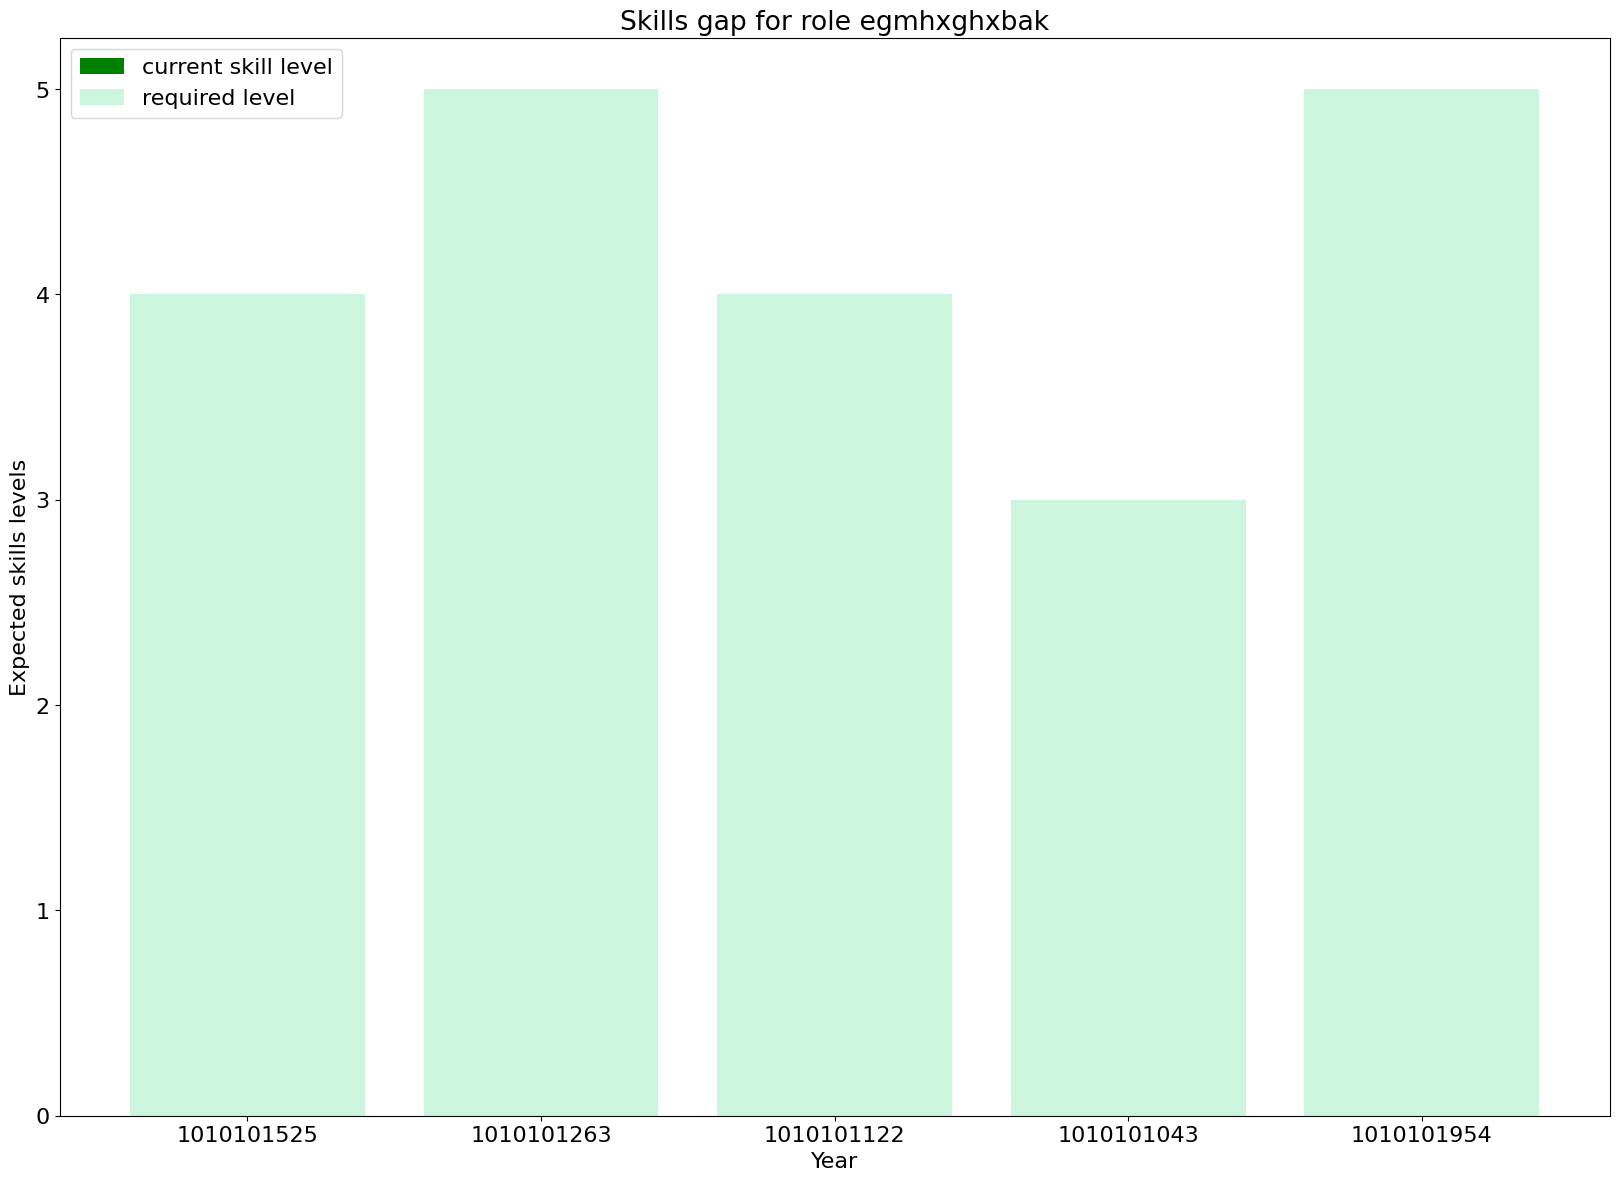

In [165]:
rows = job_skills_pd.role.str.contains(roles[0])
X = job_skills_pd.loc[rows,'skill'].to_list()
Y_level = job_skills_pd.loc[rows,'level'].to_list()
Y_req  = job_skills_pd.loc[rows,'level requirement'].to_list()
plt.bar(X, Y_level, color="green", label='current skill level')
plt.bar(X, Y_req,color='#cbf5dd', label= "required level")
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Expected skills levels")
plt.title("Skills gap for role " + roles[0])
plt.legend()
plt.show()

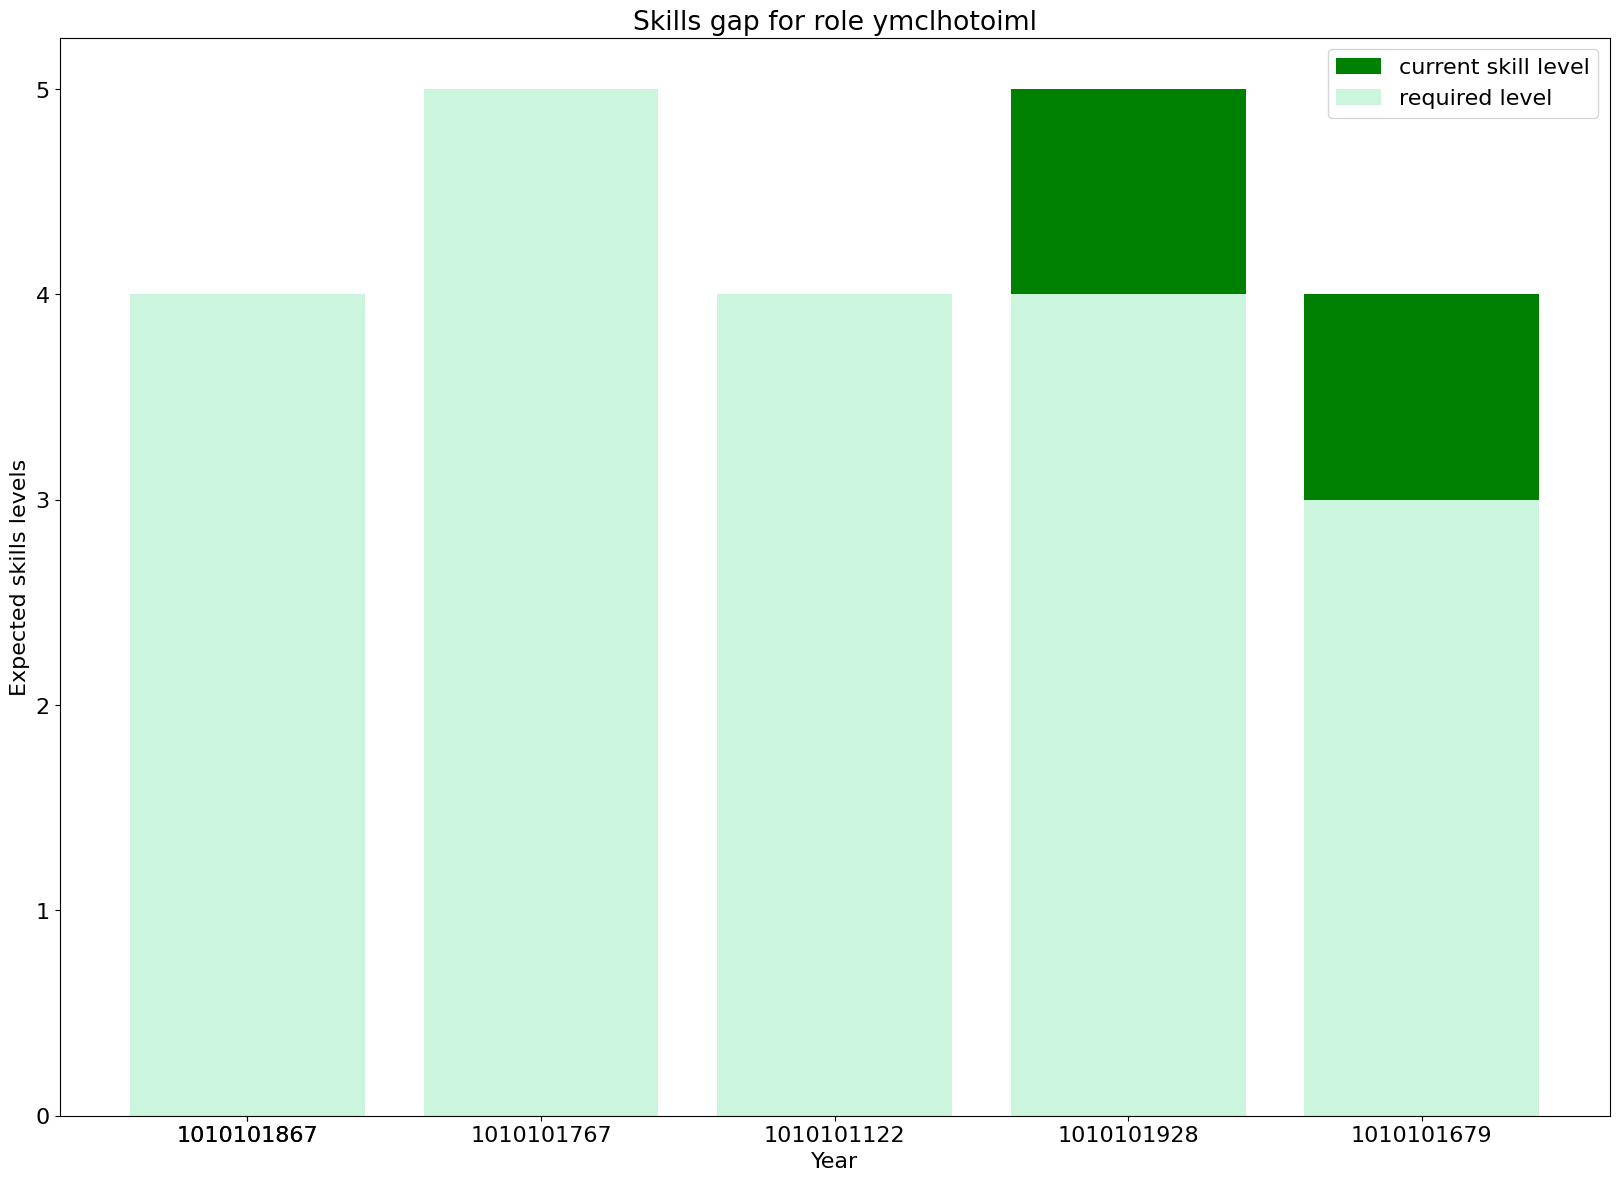

In [166]:
rows = job_skills_pd.role.str.contains(roles[1])
X = job_skills_pd.loc[rows,'skill'].to_list()
Y_level = job_skills_pd.loc[rows,'level'].to_list()
Y_req  = job_skills_pd.loc[rows,'level requirement'].to_list()
plt.bar(X, Y_level, color="green", label='current skill level')
plt.bar(X, Y_req,color='#cbf5dd', label= "required level")
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Expected skills levels")
plt.title("Skills gap for role " + roles[1])
plt.legend()
plt.show()

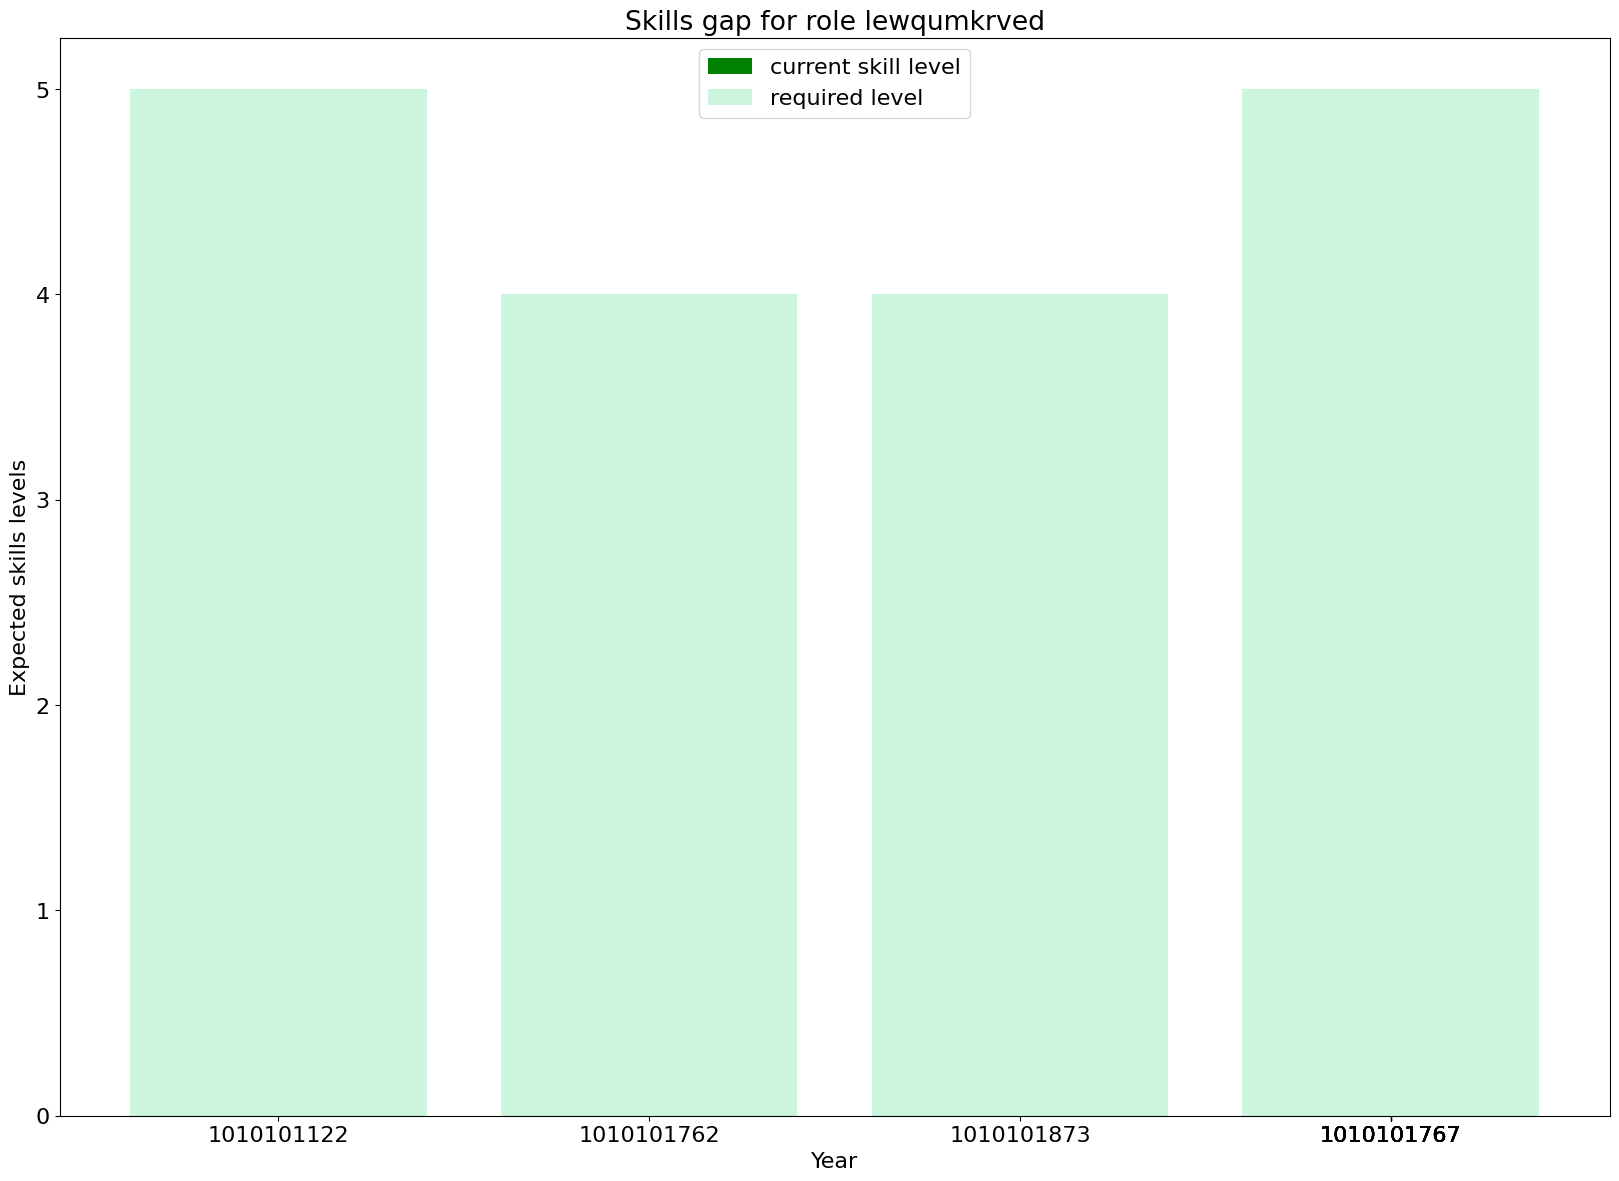

In [167]:
rows = job_skills_pd.role.str.contains(roles[2])
X = job_skills_pd.loc[rows,'skill'].to_list()
Y_level = job_skills_pd.loc[rows,'level'].to_list()
Y_req  = job_skills_pd.loc[rows,'level requirement'].to_list()
plt.bar(X, Y_level, color="green", label='current skill level')
plt.bar(X, Y_req,color='#cbf5dd', label= "required level")
plt.xticks(X)
plt.xlabel("Year")
plt.ylabel("Expected skills levels")
plt.title("Skills gap for role " + roles[2])
plt.legend()
plt.show()

# X-gov and societal analysis

## Dimensions


In [168]:
n_2023 = 100

### employees features

In [169]:
ceis = random.choices(employees_pd.ceis, k = n_2023)
rows = employees_pd.ceis.isin(ceis)
cols = ['background','marital status','gender', 'carers']
emp_details = employees_pd.loc[rows, cols].copy(deep = True)
emp_details

,background,marital status,gender,carers
0,3,0,1,2
1,2,1,1,0
3,2,0,1,4
9,4,0,0,0
12,2,0,1,0
...,...,...,...,...
285,4,0,0,0
288,0,3,0,4
290,0,3,1,2
291,5,1,1,3


In [170]:
emp = np.random.randint(100000, size=emp_details.shape[0])
emp_details['employee'] = emp
emp_details

,background,marital status,gender,carers,employee
0,3,0,1,2,16160
1,2,1,1,0,869
3,2,0,1,4,72199
9,4,0,0,0,3495
12,2,0,1,0,2794
...,...,...,...,...,...
285,4,0,0,0,13124
288,0,3,0,4,7906
290,0,3,1,2,37981
291,5,1,1,3,78433


In [171]:
emp_details['organisation'] = random.choices(organisations_pd['organisation'], k = emp_details.shape[0])
emp_details


,background,marital status,gender,carers,employee,organisation
0,3,0,1,2,16160,mzyxsukirqawtcybjvll
1,2,1,1,0,869,mzyxsukirqawtcybjvll
3,2,0,1,4,72199,mzyxsukirqawtcybjvll
9,4,0,0,0,3495,nyfslxinrpbxjjmcvumo
12,2,0,1,0,2794,jcsurldsnmgzlowgykoi
...,...,...,...,...,...,...
285,4,0,0,0,13124,ogefzchrhslcymyobvml
288,0,3,0,4,7906,wuemqowtlvvboneqjkpm
290,0,3,1,2,37981,bsgsxowefpwemmycgrgd
291,5,1,1,3,78433,wuemqowtlvvboneqjkpm


In [172]:
roles_pd

,role id,role,skill,level
0,ROLE_989543,naqdldozwyh,1010101043,3
1,ROLE_329525,cqljjdixacw,1010101772,3
2,ROLE_025947,sevplprmtbx,1010101176,4
3,ROLE_743948,joyilptjvft,1010101652,5
4,ROLE_482449,aedtathfnkb,1010101910,4
...,...,...,...,...
95,ROLE_281011,enmugvlbsfl,1010101952,5
96,ROLE_943766,kjqoddkwefj,1010101822,3
97,ROLE_185077,pfapomtdxcc,1010101762,3
98,ROLE_440020,zrztiwjkkiv,1010101987,4


In [173]:
roles_ls = random.choices(roles_pd['role id'].unique(), k = emp_details.shape[0])
emp_roles = pd.DataFrame()
emp_roles['role'] = roles_ls
emp_roles['employee'] = emp
emp_roles


,role,employee
0,ROLE_908034,16160
1,ROLE_576427,869
2,ROLE_060023,72199
3,ROLE_096991,3495
4,ROLE_041208,2794
...,...,...
79,ROLE_658943,13124
80,ROLE_208288,7906
81,ROLE_658943,37981
82,ROLE_113664,78433


In [174]:
rows = roles_pd['role id'].isin(roles_ls)
roles = roles_pd.loc[rows,:]
roles =roles.merge(emp_roles, left_on='role id', right_on='role')
roles



,role id,role_x,skill,level,role_y,employee
0,ROLE_989543,naqdldozwyh,1010101043,3,ROLE_989543,16856
1,ROLE_989543,naqdldozwyh,1010101043,3,ROLE_989543,4432
2,ROLE_329525,cqljjdixacw,1010101772,3,ROLE_329525,98494
3,ROLE_329525,cqljjdixacw,1010101772,3,ROLE_329525,52282
4,ROLE_670811,tldkrglonlc,1010101525,3,ROLE_670811,92966
...,...,...,...,...,...,...
415,ROLE_988646,qdyzkuyreat,1010101952,4,ROLE_988646,50156
416,ROLE_875141,jldxlacorig,1010101987,3,ROLE_875141,59794
417,ROLE_185077,pfapomtdxcc,1010101762,3,ROLE_185077,78023
418,ROLE_060023,rrsdulwsydt,1010101789,4,ROLE_060023,72199


In [175]:
cols = ['role_x','skill','level','employee']
roles = roles.loc[:,cols]
roles

,role_x,skill,level,employee
0,naqdldozwyh,1010101043,3,16856
1,naqdldozwyh,1010101043,3,4432
2,cqljjdixacw,1010101772,3,98494
3,cqljjdixacw,1010101772,3,52282
4,tldkrglonlc,1010101525,3,92966
...,...,...,...,...
415,qdyzkuyreat,1010101952,4,50156
416,jldxlacorig,1010101987,3,59794
417,pfapomtdxcc,1010101762,3,78023
418,rrsdulwsydt,1010101789,4,72199


Bring skills to record from the job role description. We are assuming many of level ranges between 1 and 4 for demo purposes.

In [176]:
taxonomy.columns

Index(['skill_id', 'skill', 'language', 'technical', 'soft', 'cluster',
       'function', 'profession', 'guk'],
      dtype='object')

In [177]:
roles_tax = roles.merge(taxonomy, left_on = 'skill', right_on = 'skill_id')
cols = ['role_x','level','skill_y','language','technical','soft','cluster','function','profession','guk','skill_id','employee']
roles_tax = roles_tax.loc[:, cols]
roles_tax

,role_x,level,skill_y,language,technical,soft,cluster,function,profession,guk,skill_id,employee
0,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101043,16856
1,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101043,4432
2,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,1010101772,98494
3,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,1010101772,52282
4,tldkrglonlc,3,ilkukl,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101525,92966
...,...,...,...,...,...,...,...,...,...,...,...,...
514,pfapomtdxcc,3,oksacc,False,False,True,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,1010101762,78023
515,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,1010101789,72199
516,rrsdulwsydt,4,dypppp,False,True,False,dkhk,akvrfsup,fcftnao,ldlmayhvvq,1010101789,72199
517,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,1010101789,52964


In [178]:
roles_tax['current level'] = random.choices([0,1,2,3,4], k = roles_tax.shape[0])
roles_tax['self'] = True
roles_tax['course'] = False
roles_tax['user'] = False
roles_tax


,role_x,level,skill_y,language,technical,soft,cluster,function,profession,guk,skill_id,employee,current level,self,course,user
0,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101043,16856,0,True,False,False
1,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101043,4432,3,True,False,False
2,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,1010101772,98494,2,True,False,False
3,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,1010101772,52282,0,True,False,False
4,tldkrglonlc,3,ilkukl,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq,1010101525,92966,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,pfapomtdxcc,3,oksacc,False,False,True,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,1010101762,78023,2,True,False,False
515,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,1010101789,72199,0,True,False,False
516,rrsdulwsydt,4,dypppp,False,True,False,dkhk,akvrfsup,fcftnao,ldlmayhvvq,1010101789,72199,0,True,False,False
517,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,1010101789,52964,1,True,False,False


In [179]:
roles_tax  = roles_tax.merge(emp_details, left_on='employee',right_on='employee')
roles_tax

,role_x,level,skill_y,language,technical,soft,cluster,function,profession,guk,...,employee,current level,self,course,user,background,marital status,gender,carers,organisation
0,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,...,16856,0,True,False,False,0,2,0,1,nyfslxinrpbxjjmcvumo
1,naqdldozwyh,3,ijzffe,False,True,False,efit,akvrfsup,wrtttwd,ldlmayhvvq,...,4432,3,True,False,False,2,1,1,2,ogefzchrhslcymyobvml
2,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,...,98494,2,True,False,False,1,0,0,2,nyfslxinrpbxjjmcvumo
3,cqljjdixacw,3,wakpbw,True,False,False,whxk,easpvjiy,usxhuhz,hpqmmbgtev,...,52282,0,True,False,False,3,3,0,1,bsgsxowefpwemmycgrgd
4,tldkrglonlc,3,ilkukl,False,False,True,efit,akvrfsup,wrtttwd,ldlmayhvvq,...,92966,0,True,False,False,0,3,0,1,ctahjrijfpxqakqlneyk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,pfapomtdxcc,3,oksacc,False,False,True,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,...,78023,2,True,False,False,1,0,1,1,jcsurldsnmgzlowgykoi
515,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,...,72199,0,True,False,False,2,0,1,4,mzyxsukirqawtcybjvll
516,rrsdulwsydt,4,dypppp,False,True,False,dkhk,akvrfsup,fcftnao,ldlmayhvvq,...,72199,0,True,False,False,2,0,1,4,mzyxsukirqawtcybjvll
517,rrsdulwsydt,4,dypppp,False,True,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,...,52964,1,True,False,False,5,3,1,1,ktfqqxpnwoznbyttjmlo


In [180]:
columns = ['employee',
           'marital status',
           'gender',
           'background',
           'carers',
           'organisation',
           'role_x',
           'level',
           'current level',
           'skill_y',
           'language',
           'technical',
           'soft',
           'self',
           'user',
           'course',
           'cluster',
           'function',
           'profession',
           'guk']
roles_tax = roles_tax.loc[:,columns]
roles_tax['month'] = random.choices([1,2,3,4,5,6,7,8,9,10,11,12], k=roles_tax.shape[0])
roles_tax['year']  = np.repeat(2023, roles_tax.shape[0])
new  = ['employee', 'marital status','gender','background','carer', 'organisation', 'role', 'level required', 'current level', 'skill', 'language', "technical",'soft', 'self', 'user', 'course', 'cluster', 'function', 'profession', 'guk', 'month', 'year']
roles_tax.columns = new
roles_tax.dtypes



employee           int64
marital status     int64
gender             int64
background         int64
carer              int64
organisation      object
role              object
level required     int64
current level      int64
skill             object
language            bool
technical           bool
soft                bool
self                bool
user                bool
course              bool
cluster           object
function          object
profession        object
guk               object
month              int64
year               int64
dtype: object

In [181]:
roles_tax.groupby(['employee','role','skill']).count().describe()


,marital status,gender,background,carer,organisation,level required,current level,language,technical,soft,self,user,course,cluster,function,profession,guk,month,year
count,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000
mean,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292,1.166292
std,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404,0.407404
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


self assessed skills

In [182]:
roles_tax.dtypes


employee           int64
marital status     int64
gender             int64
background         int64
carer              int64
organisation      object
role              object
level required     int64
current level      int64
skill             object
language            bool
technical           bool
soft                bool
self                bool
user                bool
course              bool
cluster           object
function          object
profession        object
guk               object
month              int64
year               int64
dtype: object

In [183]:
self = emp_details.copy(deep=True)
self = self.merge(emp_roles, left_on='employee', right_on='employee')
self = self.merge(roles_pd, left_on='role', right_on='role id')
self = self.loc[:,['employee','role_y']]
self = self.drop_duplicates()
n = self.shape[0]
self['level'] = np.repeat(0, n)
self.columns =['employee','role','level']
self


,employee,role,level
0,16160,ckrqfhcfdvp,0
5,869,oglugxxotod,0
10,72199,rrsdulwsydt,0
15,3495,tnpgicxmtco,0
20,2794,syjprfieszh,0
...,...,...,...
395,13124,mqxcxxjuodf,0
400,7906,kbmzzbozsfw,0
405,37981,mqxcxxjuodf,0
410,78433,unnqapiiipf,0


In [184]:
skills_pd.head()

,skills_uid,skills,language,technical,soft,cluster
0,1010101263,gqryuk,False,True,False,2020202265
1,1010101987,goaylk,True,False,False,2020202454
2,1010101349,bdbluo,True,False,False,2020202005
3,1010101080,bsncme,False,True,False,2020202005
4,1010101952,bxxnst,False,False,True,2020202703


In [185]:
skills = random.choices(skills_pd.skills_uid, k=self.shape[0])
self['skill'] = skills
rows = skills_pd.skills_uid.isin(skills)
skills = skills_pd.loc[rows, :]
self = self.merge(skills_pd, left_on = 'skill', right_on="skills_uid")
self['current level'] = random.choices([3,4,5], k=self.shape[0])
self['self']  = True
self['user']  = False
self['course']  = False
self

,employee,role,level,skill,skills_uid,skills,language,technical,soft,cluster,current level,self,user,course
0,16160,ckrqfhcfdvp,0,1010101349,1010101349,bdbluo,True,False,False,2020202005,5,True,False,False
1,869,oglugxxotod,0,1010101652,1010101652,dbbyzn,False,True,False,2020202005,3,True,False,False
2,72199,rrsdulwsydt,0,1010101767,1010101767,gbhazb,False,True,False,2020202005,3,True,False,False
3,72199,rrsdulwsydt,0,1010101767,1010101767,jisdwl,False,False,True,2020202043,5,True,False,False
4,3495,tnpgicxmtco,0,1010101586,1010101586,jracpf,False,True,False,2020202043,3,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,13124,mqxcxxjuodf,0,1010101070,1010101070,smkggd,True,False,False,2020202005,4,True,False,False
89,7906,kbmzzbozsfw,0,1010101789,1010101789,dypppp,False,True,False,2020202215,3,True,False,False
90,37981,mqxcxxjuodf,0,1010101691,1010101691,brxfmi,False,False,True,2020202378,3,True,False,False
91,78433,unnqapiiipf,0,1010101881,1010101881,ndrenb,False,False,True,2020202888,3,True,False,False


In [186]:
taxonomy.columns

Index(['skill_id', 'skill', 'language', 'technical', 'soft', 'cluster',
       'function', 'profession', 'guk'],
      dtype='object')

In [187]:
self = self.merge(taxonomy, left_on ='skills_uid', right_on='skill_id')
self = self.merge(emp_details, left_on = "employee", right_on="employee")

self

,employee,role,level,skill_x,skills_uid,skills,language_x,technical_x,soft_x,cluster_x,...,soft_y,cluster_y,function,profession,guk,background,marital status,gender,carers,organisation
0,16160,ckrqfhcfdvp,0,1010101349,1010101349,bdbluo,True,False,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,3,0,1,2,mzyxsukirqawtcybjvll
1,869,oglugxxotod,0,1010101652,1010101652,dbbyzn,False,True,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,1,1,0,mzyxsukirqawtcybjvll
2,72199,rrsdulwsydt,0,1010101767,1010101767,gbhazb,False,True,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,0,1,4,mzyxsukirqawtcybjvll
3,72199,rrsdulwsydt,0,1010101767,1010101767,gbhazb,False,True,False,2020202005,...,True,plnm,hyhbuafh,unsdcqf,ldlmayhvvq,2,0,1,4,mzyxsukirqawtcybjvll
4,72199,rrsdulwsydt,0,1010101767,1010101767,jisdwl,False,False,True,2020202043,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,0,1,4,mzyxsukirqawtcybjvll
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,7906,kbmzzbozsfw,0,1010101789,1010101789,dypppp,False,True,False,2020202215,...,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,0,3,0,4,wuemqowtlvvboneqjkpm
115,7906,kbmzzbozsfw,0,1010101789,1010101789,dypppp,False,True,False,2020202215,...,False,dkhk,akvrfsup,fcftnao,ldlmayhvvq,0,3,0,4,wuemqowtlvvboneqjkpm
116,37981,mqxcxxjuodf,0,1010101691,1010101691,brxfmi,False,False,True,2020202378,...,True,efit,akvrfsup,wrtttwd,ldlmayhvvq,0,3,1,2,bsgsxowefpwemmycgrgd
117,78433,unnqapiiipf,0,1010101881,1010101881,ndrenb,False,False,True,2020202888,...,True,upnl,akvrfsup,wrtttwd,ldlmayhvvq,5,1,1,3,wuemqowtlvvboneqjkpm


In [188]:
self.head()


,employee,role,level,skill_x,skills_uid,skills,language_x,technical_x,soft_x,cluster_x,...,soft_y,cluster_y,function,profession,guk,background,marital status,gender,carers,organisation
0,16160,ckrqfhcfdvp,0,1010101349,1010101349,bdbluo,True,False,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,3,0,1,2,mzyxsukirqawtcybjvll
1,869,oglugxxotod,0,1010101652,1010101652,dbbyzn,False,True,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,1,1,0,mzyxsukirqawtcybjvll
2,72199,rrsdulwsydt,0,1010101767,1010101767,gbhazb,False,True,False,2020202005,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,0,1,4,mzyxsukirqawtcybjvll
3,72199,rrsdulwsydt,0,1010101767,1010101767,gbhazb,False,True,False,2020202005,...,True,plnm,hyhbuafh,unsdcqf,ldlmayhvvq,2,0,1,4,mzyxsukirqawtcybjvll
4,72199,rrsdulwsydt,0,1010101767,1010101767,jisdwl,False,False,True,2020202043,...,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,2,0,1,4,mzyxsukirqawtcybjvll


columns = ['employee',
           'organisation',
           'role',
           'level required',
           'current level',
           'skill',
           'language',
           'soft',
           'self',
           'user',
           'course',
           'cluster',
           'function',
           'profession',
           'guk',
           'month',
           'year']


In [189]:
columns = ['employee',
           'marital status',
           'gender',
           'background',
           'carers',
           'organisation',
           'role',
           'level',
           'current level',
           'skill_y',
           'language_x',
           'technical_x',
           'soft_x',
           'self',
           'user',
           'course',
           'cluster_y',
           'function',
           'profession',
           'guk']

self = self.loc[:,columns]
self['month'] = random.choices([1,2,3,4,5,6,7,8,9,10,11,12], k=self.shape[0])
self['year']  = np.repeat(2023, self.shape[0])
new  = ['employee', 'marital status','gender','background','carer', 'organisation', 'role', 'level required', 'current level', 'skill', 'language', "technical",'soft', 'self', 'user', 'course', 'cluster', 'function', 'profession', 'guk', 'month', 'year']
self.columns = new
self.dtypes



employee           int64
marital status     int64
gender             int64
background         int64
carer              int64
organisation      object
role              object
level required     int64
current level      int64
skill             object
language            bool
technical           bool
soft                bool
self                bool
user                bool
course              bool
cluster           object
function          object
profession        object
guk               object
month              int64
year               int64
dtype: object

In [190]:
self.dtypes

employee           int64
marital status     int64
gender             int64
background         int64
carer              int64
organisation      object
role              object
level required     int64
current level      int64
skill             object
language            bool
technical           bool
soft                bool
self                bool
user                bool
course              bool
cluster           object
function          object
profession        object
guk               object
month              int64
year               int64
dtype: object

In [191]:
org_skills_pd = pd.concat([self,roles_tax])
org_skills_pd

,employee,marital status,gender,background,carer,organisation,role,level required,current level,skill,...,soft,self,user,course,cluster,function,profession,guk,month,year
0,16160,0,1,3,2,mzyxsukirqawtcybjvll,ckrqfhcfdvp,0,5,bdbluo,...,False,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,3,2023
1,869,1,1,2,0,mzyxsukirqawtcybjvll,oglugxxotod,0,3,dbbyzn,...,False,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,10,2023
2,72199,0,1,2,4,mzyxsukirqawtcybjvll,rrsdulwsydt,0,3,gbhazb,...,False,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,1,2023
3,72199,0,1,2,4,mzyxsukirqawtcybjvll,rrsdulwsydt,0,3,jisdwl,...,False,True,False,False,plnm,hyhbuafh,unsdcqf,ldlmayhvvq,9,2023
4,72199,0,1,2,4,mzyxsukirqawtcybjvll,rrsdulwsydt,0,5,gbhazb,...,True,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,4,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,78023,0,1,1,1,jcsurldsnmgzlowgykoi,pfapomtdxcc,3,2,oksacc,...,True,True,False,False,dghm,ckzgyvfj,vmyvicq,hpqmmbgtev,12,2023
515,72199,0,1,2,4,mzyxsukirqawtcybjvll,rrsdulwsydt,4,0,dypppp,...,False,True,False,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,6,2023
516,72199,0,1,2,4,mzyxsukirqawtcybjvll,rrsdulwsydt,4,0,dypppp,...,False,True,False,False,dkhk,akvrfsup,fcftnao,ldlmayhvvq,11,2023
517,52964,3,1,5,1,ktfqqxpnwoznbyttjmlo,rrsdulwsydt,4,1,dypppp,...,False,True,False,False,spom,hyhbuafh,bnkimlk,ldlmayhvvq,10,2023


In [192]:
org_skills_pd.dtypes

employee           int64
marital status     int64
gender             int64
background         int64
carer              int64
organisation      object
role              object
level required     int64
current level      int64
skill             object
language            bool
technical           bool
soft                bool
self                bool
user                bool
course              bool
cluster           object
function          object
profession        object
guk               object
month              int64
year               int64
dtype: object